# Unified simulated neutron and gamma radiation field

This notebook combines the measurement-specific theoretical neutron field from
Notebook 2 with the corresponding gamma field from Notebook 2.5. It retains the
physical neutron, photon, and AP-effective-dose quantities and additionally
constructs instrument-equivalent proxies for comparison with the measurement-only
outputs from Notebook 5.

The physical combined AP-effective-dose-rate estimate is

$$
\dot E_{\mathrm{AP,tot}}
=
\dot E_{\mathrm{AP,n}}
+
\dot E_{\mathrm{AP,\gamma}}.
$$

The comparison quantity exported to Notebook 6 is instead

$$
\dot H_{\mathrm{combined,sim-ind}}
=
\dot H_{\mathrm{n,2202D-eq,sim}}
+
\dot H_{\mathrm{\gamma,GCA-Cs137-eq,sim}}.
$$

The two terms are response-labelled proxies, not a claim that OpenMC reproduces
the complete electronics of either instrument. The manuals do not provide full
numerical energy- and angle-response functions. The neutron proxy therefore uses
the spectrum-weighted neutron dose field at the Studsvik reference centre, while
the gamma proxy uses the LND 712 detector-specific gamma field with a Cs-137
reference conversion. Their sum is an instrument-comparison field, not AP
effective dose. Experimental measurements remain confined to Notebook 5.

# 1) Setup, shared source model, and analysis conventions

Notebook 3 uses the same geometry, materials, source record, experiment date,
and ALPHANSO source distributions as the corrected Notebook 2 and Notebook 2.5
workflows.

The reported numerical uncertainties in this notebook are OpenMC
batch-statistical standard uncertainties only. They do not include uncertainty
from the source certificate, decay correction, ALPHANSO yields or spectra,
geometry, materials, nuclear data, or detector response.


In [2]:
from pathlib import Path
import importlib
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

import openmc
import ambe_base_model


# Reload after deliberate edits to the shared module.
importlib.reload(ambe_base_model)


# ------------------------------------------------------------
# Physical normalization date
# ------------------------------------------------------------

EXPERIMENT_DATE = "2026-03-15"


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path("N3_simulated_unified_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Shared model and source record
# ------------------------------------------------------------

base = ambe_base_model.build_base_model(
    export_xml=False,
    verbose=True,
    source_evaluation_date=EXPERIMENT_DATE,
)

globals().update(base)

required_base_names = [
    "geometry",
    "materials",
    "CABINET_ZMIN",
    "SOURCE_MANUFACTURER",
    "SOURCE_MODEL",
    "SOURCE_SERIAL_NUMBER",
    "SOURCE_NEUTRON_EMISSION_REF",
    "SOURCE_NEUTRON_EMISSION_REF_DATE",
    "SOURCE_NEUTRON_EMISSION",
    "SOURCE_EVALUATION_DATE",
    "SOURCE_NORMALIZATION_STATUS",
]

missing_base_names = [
    name for name in required_base_names
    if name not in globals()
]

if missing_base_names:
    raise NameError(
        "The shared base model is missing: "
        + ", ".join(missing_base_names)
    )

if SOURCE_EVALUATION_DATE != EXPERIMENT_DATE:
    raise ValueError(
        "The shared source model did not use the selected experiment date. "
        f"Expected {EXPERIMENT_DATE}, got {SOURCE_EVALUATION_DATE}."
    )


# ------------------------------------------------------------
# Neutron and gamma source distributions
# ------------------------------------------------------------

neutron_energy_dist = ambe_base_model.build_ambe_energy_distribution(
    make_plot=False,
    verbose=False,
)

gamma_energy_dist, gamma_data = (
    ambe_base_model.build_ambe_gamma_line_distribution(
        make_plot=False,
        verbose=True,
    )
)

alphanso_results = gamma_data.get("alphanso_results")

if not isinstance(alphanso_results, dict):
    raise RuntimeError(
        "ALPHANSO results are required for the final gamma-source "
        "normalization."
    )

if "an_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["an_yield"])
    alphanso_neutron_yield_key = "an_yield"
elif "combined_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["combined_yield"])
    alphanso_neutron_yield_key = "combined_yield"
else:
    raise KeyError(
        "ALPHANSO results contain neither 'an_yield' nor "
        "'combined_yield'."
    )

alphanso_gamma_yield = float(gamma_data["gamma_yield"])

for name, value in [
    ("ALPHANSO neutron yield", alphanso_neutron_yield),
    ("ALPHANSO gamma yield", alphanso_gamma_yield),
]:
    if not np.isfinite(value) or value <= 0.0:
        raise ValueError(f"{name} must be finite and positive; got {value}.")

GAMMA_TO_NEUTRON_RATIO_ALPHANSO = (
    alphanso_gamma_yield / alphanso_neutron_yield
)

GAMMA_SOURCE_EMISSION = (
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO
    * SOURCE_NEUTRON_EMISSION
)

GAMMA_SOURCE_NORMALIZATION_STATUS = (
    "decay-corrected source-specific neutron emission multiplied by the "
    "ALPHANSO total gamma-to-neutron yield ratio"
)


# ------------------------------------------------------------
# Monte Carlo uncertainty convention
# ------------------------------------------------------------

MC_LOW_U_MAX_PERCENT = 5.0
MC_MODERATE_U_MAX_PERCENT = 10.0
MC_HIGH_U_MAX_PERCENT = 25.0

# Notebook 2.5 did not reach its originally configured 10% group-1 target.
# Its flux estimates and actual pointwise uncertainties are nevertheless retained
# for the GCA-equivalent proxy. This switch permits that documented handoff.
ALLOW_UNCONVERGED_N2_5_GAMMA_INPUT = True
N2_5_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT = 50.0

MC_UNCERTAINTY_ORDER = [
    "low",
    "moderate",
    "high",
    "very high",
    "unknown",
]


def classify_relative_mc_uncertainty(relative_uncertainty_percent):
    if not np.isfinite(relative_uncertainty_percent):
        return "unknown"
    if relative_uncertainty_percent < MC_LOW_U_MAX_PERCENT:
        return "low"
    if relative_uncertainty_percent < MC_MODERATE_U_MAX_PERCENT:
        return "moderate"
    if relative_uncertainty_percent < MC_HIGH_U_MAX_PERCENT:
        return "high"
    return "very high"


# ------------------------------------------------------------
# Shared P1--P5 plot style
# ------------------------------------------------------------

POSITION_ORDER = ["P1", "P2", "P3", "P4", "P5"]

POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}


def lighten_color(color, amount):
    """Blend a Matplotlib colour with white."""

    base_rgb = np.asarray(to_rgb(color), dtype=float)
    white_rgb = np.ones(3)
    return tuple((1.0 - amount) * base_rgb + amount * white_rgb)


def make_position_height_colors(dataframe):
    """Return fixed position colours with lighter shades at higher heights."""

    color_map = {}

    for position in POSITION_ORDER:
        heights = np.sort(
            dataframe.loc[
                dataframe["position"] == position,
                "height_cm",
            ]
            .dropna()
            .unique()
        )

        if len(heights) == 0:
            continue

        if len(heights) == 1:
            lightening_amounts = np.array([0.0])
        else:
            lightening_amounts = np.linspace(0.0, 0.48, len(heights))

        for height_cm, amount in zip(heights, lightening_amounts):
            color_map[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position],
                amount,
            )

    return color_map


print("Notebook 3 setup complete.")
print(f"Physical source:            {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(
    "Factory neutron emission:  "
    f"{SOURCE_NEUTRON_EMISSION_REF:.6e} n/s on "
    f"{SOURCE_NEUTRON_EMISSION_REF_DATE}"
)
print(
    "Selected neutron emission: "
    f"{SOURCE_NEUTRON_EMISSION:.6e} n/s on "
    f"{SOURCE_EVALUATION_DATE}"
)
print(f"Gamma/neutron yield ratio: {GAMMA_TO_NEUTRON_RATIO_ALPHANSO:.6e}")
print(f"Selected gamma emission:   {GAMMA_SOURCE_EMISSION:.6e} photons/s")
print(f"Output folder:             {OUTPUT_DIR}")


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           = 0.955 cm
  Source active radius          = 0.675 cm
  Source active height          = 4.300 cm

Materials and geometry built.
Defined cells:
  13: Cabinet wall
  14: Cabinet inner air
  15: Inner paraffin block around source
  16: Outer paraffin moderator
  17: Plast

# 2) Load, match, and preserve the two flux-coordinate systems

The final neutron and gamma scan tables are loaded from Notebook 2 and Notebook
2.5. The same nominal measurement configuration is identified by
`point_name`, `position`, `distance_cm`, and `height_cm`.

The Cartesian coordinates are deliberately **not** required to be identical.
Notebook 2 reports its virtual neutron-flux cube centre, whereas Notebook 2.5
reports the centre of the LND 712 active cylinder, $1.905\ \mathrm{cm}$ behind
the mica-window plane. The final table therefore retains separate coordinate
columns for the neutron-flux tally, gamma-flux tally, and common dose tally.


In [3]:
def find_first_existing_file(candidates, label):
    """Return the first existing project file from an ordered candidate list."""

    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            print(f"Found {label}: {candidate}")
            return candidate

    candidate_text = "\n".join(f"  {Path(path)}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {label}. Tried:\n{candidate_text}"
    )


def find_first_existing_column(dataframe, candidates, label):
    """Return the first available column name from a compatibility list."""

    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise KeyError(
        f"Could not find {label}. Tried {candidates}. "
        f"Available columns: {dataframe.columns.tolist()}"
    )


def find_optional_column(dataframe, candidates):
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate
    return None


neutron_flux_path = find_first_existing_file(
    [
        "N2_simulated_neutron_outputs/tables/"
        "measurement_specific_neutron_scan_summary_final.csv",
        "measurement_specific_neutron_scan_summary_final.csv",
    ],
    "final neutron-flux table",
)

gamma_flux_path = find_first_existing_file(
    [
        "N2_5_simulated_gamma_outputs/tables/"
        "measurement_specific_gamma_scan_summary_final.csv",
        "measurement_specific_gamma_scan_summary_final.csv",
    ],
    "final LND 712 gamma-flux table",
)

neutron_flux_raw = pd.read_csv(neutron_flux_path)
gamma_flux_raw = pd.read_csv(gamma_flux_path)


MATCH_COLUMNS = [
    "point_name",
    "position",
    "distance_cm",
    "height_cm",
]
INPUT_COORDINATE_COLUMNS = ["x_cm", "y_cm", "z_cm"]
REQUIRED_INPUT_COLUMNS = MATCH_COLUMNS + INPUT_COORDINATE_COLUMNS

for table_name, dataframe in [
    ("neutron", neutron_flux_raw),
    ("gamma", gamma_flux_raw),
]:
    missing_columns = [
        column for column in REQUIRED_INPUT_COLUMNS
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The {table_name} flux table is missing required columns: "
            + ", ".join(missing_columns)
        )

    if dataframe["point_name"].duplicated().any():
        duplicates = dataframe.loc[
            dataframe["point_name"].duplicated(keep=False),
            "point_name",
        ].tolist()
        raise ValueError(
            f"The {table_name} table contains duplicate point names: "
            f"{duplicates[:10]}"
        )


neutron_flux_value_col = find_first_existing_column(
    neutron_flux_raw,
    ["flux_physical [n/cm2/s]", "neutron_flux [n/cm2/s]"],
    "physical neutron-flux column",
)
neutron_flux_u_col = find_first_existing_column(
    neutron_flux_raw,
    [
        "u_mc_physical [n/cm2/s]",
        "std_physical [n/cm2/s]",
        "neutron_flux_std [n/cm2/s]",
    ],
    "neutron-flux MC standard-uncertainty column",
)
neutron_flux_rel_u_col = find_first_existing_column(
    neutron_flux_raw,
    ["rel_u_mc [%]", "rel_unc [%]", "neutron_flux_rel_unc [%]"],
    "relative neutron-flux MC uncertainty column",
)

gamma_flux_value_col = find_first_existing_column(
    gamma_flux_raw,
    [
        "gamma_flux_physical [photon/cm2/s]",
        "gamma_flux [photon/cm2/s]",
    ],
    "physical gamma-flux column",
)
gamma_flux_u_col = find_first_existing_column(
    gamma_flux_raw,
    [
        "u_mc_physical [photon/cm2/s]",
        "gamma_std_physical [photon/cm2/s]",
        "gamma_flux_std [photon/cm2/s]",
    ],
    "gamma-flux MC standard-uncertainty column",
)
gamma_flux_rel_u_col = find_first_existing_column(
    gamma_flux_raw,
    ["rel_u_mc [%]", "rel_unc [%]", "gamma_flux_rel_unc [%]"],
    "relative gamma-flux MC uncertainty column",
)

neutron_volume_col = find_optional_column(
    neutron_flux_raw,
    ["detector_volume_cm3", "tally_volume_cm3"],
)
gamma_volume_col = find_optional_column(
    gamma_flux_raw,
    ["detector_volume_cm3", "tally_volume_cm3"],
)


neutron_flux_df = neutron_flux_raw[
    REQUIRED_INPUT_COLUMNS
    + [
        neutron_flux_value_col,
        neutron_flux_u_col,
        neutron_flux_rel_u_col,
    ]
    + ([neutron_volume_col] if neutron_volume_col else [])
].copy()

neutron_flux_df = neutron_flux_df.rename(columns={
    "x_cm": "neutron_flux_x_cm",
    "y_cm": "neutron_flux_y_cm",
    "z_cm": "neutron_flux_z_cm",
    neutron_flux_value_col: "neutron_flux [n/cm2/s]",
    neutron_flux_u_col: "u_mc_neutron_flux [n/cm2/s]",
    neutron_flux_rel_u_col: "rel_u_mc_neutron_flux [%]",
})

if neutron_volume_col:
    neutron_flux_df = neutron_flux_df.rename(columns={
        neutron_volume_col: "neutron_flux_tally_volume_cm3",
    })
else:
    neutron_flux_df["neutron_flux_tally_volume_cm3"] = np.nan


gamma_flux_df = gamma_flux_raw[
    REQUIRED_INPUT_COLUMNS
    + [
        gamma_flux_value_col,
        gamma_flux_u_col,
        gamma_flux_rel_u_col,
    ]
    + ([gamma_volume_col] if gamma_volume_col else [])
].copy()

gamma_flux_df = gamma_flux_df.rename(columns={
    "x_cm": "gamma_flux_x_cm",
    "y_cm": "gamma_flux_y_cm",
    "z_cm": "gamma_flux_z_cm",
    gamma_flux_value_col: "gamma_flux [photon/cm2/s]",
    gamma_flux_u_col: "u_mc_gamma_flux [photon/cm2/s]",
    gamma_flux_rel_u_col: "rel_u_mc_gamma_flux [%]",
})

if gamma_volume_col:
    gamma_flux_df = gamma_flux_df.rename(columns={
        gamma_volume_col: "gamma_flux_tally_volume_cm3",
    })
else:
    gamma_flux_df["gamma_flux_tally_volume_cm3"] = np.nan


expected_point_count = 61

for table_name, dataframe in [
    ("neutron", neutron_flux_df),
    ("gamma", gamma_flux_df),
]:
    if len(dataframe) != expected_point_count:
        raise ValueError(
            f"The {table_name} flux table must contain "
            f"{expected_point_count} points; found {len(dataframe)}."
        )


point_alignment = neutron_flux_df[
    MATCH_COLUMNS
    + ["neutron_flux_x_cm", "neutron_flux_y_cm", "neutron_flux_z_cm"]
].merge(
    gamma_flux_df[
        MATCH_COLUMNS
        + ["gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm"]
    ],
    on="point_name",
    how="outer",
    suffixes=("_neutron", "_gamma"),
    indicator=True,
    validate="one_to_one",
)

if not (point_alignment["_merge"] == "both").all():
    unmatched = point_alignment.loc[
        point_alignment["_merge"] != "both",
        ["point_name", "_merge"],
    ]
    raise ValueError(
        "Neutron and gamma flux tables do not contain the same nominal "
        f"measurement configurations:\n{unmatched.to_string(index=False)}"
    )

if not (
    point_alignment["position_neutron"].astype(str)
    == point_alignment["position_gamma"].astype(str)
).all():
    raise ValueError("Neutron and gamma position labels are inconsistent.")

for nominal_coordinate in ["distance_cm", "height_cm"]:
    difference = np.abs(
        point_alignment[f"{nominal_coordinate}_neutron"].astype(float)
        - point_alignment[f"{nominal_coordinate}_gamma"].astype(float)
    )
    if np.nanmax(difference) > 1.0e-9:
        raise ValueError(
            f"Neutron and gamma values disagree for {nominal_coordinate}; "
            f"maximum difference = {np.nanmax(difference):.6e} cm."
        )

for axis in ["x", "y", "z"]:
    point_alignment[f"flux_centre_delta_{axis}_cm"] = (
        point_alignment[f"gamma_flux_{axis}_cm"].astype(float)
        - point_alignment[f"neutron_flux_{axis}_cm"].astype(float)
    )

point_alignment["flux_centre_separation_cm"] = np.sqrt(
    sum(
        point_alignment[f"flux_centre_delta_{axis}_cm"]**2
        for axis in ["x", "y", "z"]
    )
)

point_count_check = (
    neutron_flux_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reindex(POSITION_ORDER)
    .reset_index()
)

print()
print("Nominal input-table matching passed.")
print(f"Neutron rows: {len(neutron_flux_df)}")
print(f"Gamma rows:   {len(gamma_flux_df)}")
print(
    "Flux-centre separation range: "
    f"{point_alignment['flux_centre_separation_cm'].min():.6f} to "
    f"{point_alignment['flux_centre_separation_cm'].max():.6f} cm"
)
display(point_count_check)


Found final neutron-flux table: N2_simulated_neutron_outputs/tables/measurement_specific_neutron_scan_summary_final.csv
Found final LND 712 gamma-flux table: N2_5_simulated_gamma_outputs/tables/measurement_specific_gamma_scan_summary_final.csv

Nominal input-table matching passed.
Neutron rows: 61
Gamma rows:   61
Flux-centre separation range: 8.845000 to 8.845000 cm


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


## 2.1) Verify source normalization, LND 712 geometry, and input precision metadata

Notebook 2 and Notebook 2.5 must use the same decay-corrected neutron source
record as this notebook. The gamma metadata are additionally checked for the
selected photon emission, ALPHANSO gamma-to-neutron yield ratio, LND 712 active
volume, configured precision target, achieved maximum uncertainty, and the
weight-window path.

Notebook 2.5 did not reach its originally configured 10% group-1 target. This
does not invalidate its independently generated `weight_windows.h5`. Notebook 3
therefore retains the Notebook 2.5 flux table and its actual pointwise
uncertainties, emits a visible warning, and continues. The unconverged input is
used only for the detector-specific GCA-equivalent proxy; Notebook 3's new gamma
dose and common-cube flux tallies undergo their own independent 50% audit.

In [4]:
def read_metadata_map(path_candidates):
    """Read a quantity/value metadata CSV when one is available."""

    for candidate in path_candidates:
        candidate = Path(candidate)
        if not candidate.exists():
            continue

        metadata_df = pd.read_csv(candidate)
        required_columns = {"quantity", "value"}

        if not required_columns.issubset(metadata_df.columns):
            raise ValueError(
                f"Metadata file {candidate} lacks quantity/value columns."
            )

        metadata_map = dict(
            zip(
                metadata_df["quantity"].astype(str),
                metadata_df["value"],
            )
        )
        return candidate, metadata_map

    candidate_text = "\n".join(f"  {Path(path)}" for path in path_candidates)
    raise FileNotFoundError(
        "Required metadata file was not found. Tried:\n" + candidate_text
    )


neutron_metadata_path, neutron_metadata = read_metadata_map([
    "N2_simulated_neutron_outputs/metadata/"
    "measurement_specific_neutron_scan_metadata.csv",
])

gamma_metadata_path, gamma_metadata = read_metadata_map([
    "N2_5_simulated_gamma_outputs/metadata/"
    "measurement_specific_gamma_scan_metadata.csv",
])


def metadata_float(metadata, key, metadata_label):
    if key not in metadata:
        raise KeyError(f"{metadata_label} metadata lack '{key}'.")
    value = float(metadata[key])
    if not np.isfinite(value):
        raise ValueError(f"{metadata_label} metadata contain invalid {key}.")
    return value


def metadata_bool(metadata, key, metadata_label):
    if key not in metadata:
        raise KeyError(f"{metadata_label} metadata lack '{key}'.")
    value = str(metadata[key]).strip().lower()
    if value in {"true", "1", "yes"}:
        return True
    if value in {"false", "0", "no"}:
        return False
    raise ValueError(
        f"{metadata_label} metadata contain an invalid Boolean for {key}: "
        f"{metadata[key]}"
    )


def validate_selected_neutron_emission(metadata, metadata_label):
    if "selected_neutron_emission" not in metadata:
        raise KeyError(
            f"{metadata_label} metadata do not contain "
            "'selected_neutron_emission'."
        )

    metadata_emission = float(metadata["selected_neutron_emission"])

    if not np.isclose(
        metadata_emission,
        SOURCE_NEUTRON_EMISSION,
        rtol=1.0e-10,
        atol=0.0,
    ):
        raise ValueError(
            f"{metadata_label} used {metadata_emission:.12e} n/s, but "
            f"Notebook 3 uses {SOURCE_NEUTRON_EMISSION:.12e} n/s."
        )

    date_key_candidates = [
        "selected_neutron_emission_date",
        "selected_neutron_emission_evaluation_date",
    ]

    for date_key in date_key_candidates:
        if date_key in metadata:
            metadata_date = str(metadata[date_key])
            if metadata_date != SOURCE_EVALUATION_DATE:
                raise ValueError(
                    f"{metadata_label} used evaluation date {metadata_date}, "
                    f"but Notebook 3 uses {SOURCE_EVALUATION_DATE}."
                )
            break


validate_selected_neutron_emission(
    neutron_metadata,
    "Notebook 2 neutron",
)

validate_selected_neutron_emission(
    gamma_metadata,
    "Notebook 2.5 gamma",
)


gamma_metadata_emission = metadata_float(
    gamma_metadata,
    "selected_gamma_emission",
    "Notebook 2.5 gamma",
)
if not np.isclose(
    gamma_metadata_emission,
    GAMMA_SOURCE_EMISSION,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "Notebook 2.5 selected gamma emission does not match Notebook 3: "
        f"{gamma_metadata_emission:.12e} versus "
        f"{GAMMA_SOURCE_EMISSION:.12e} photons/s."
    )

gamma_metadata_ratio = metadata_float(
    gamma_metadata,
    "alphanso_gamma_to_neutron_ratio",
    "Notebook 2.5 gamma",
)
if not np.isclose(
    gamma_metadata_ratio,
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "Notebook 2.5 ALPHANSO gamma/neutron ratio does not match "
        "Notebook 3."
    )

EXPECTED_LND712_VOLUME_CM3 = np.pi * (0.91 / 2.0)**2 * 3.81
GAMMA_FLUX_LND712_VOLUME_CM3 = metadata_float(
    gamma_metadata,
    "lnd712_active_tally_volume",
    "Notebook 2.5 gamma",
)
if not np.isclose(
    GAMMA_FLUX_LND712_VOLUME_CM3,
    EXPECTED_LND712_VOLUME_CM3,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "Notebook 2.5 does not report the expected LND 712 active volume."
    )

finite_gamma_volumes = gamma_flux_df[
    "gamma_flux_tally_volume_cm3"
].dropna().astype(float)
if not finite_gamma_volumes.empty and not np.allclose(
    finite_gamma_volumes,
    GAMMA_FLUX_LND712_VOLUME_CM3,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "The gamma-flux table and metadata disagree on the LND 712 volume."
    )

GROUP_1_FLUX_TARGET_PERCENT = metadata_float(
    gamma_metadata,
    "group_1_relative_error_target",
    "Notebook 2.5 gamma",
)
if GROUP_1_FLUX_TARGET_PERCENT <= 0.0:
    raise ValueError("Notebook 2.5 group-1 uncertainty target must be positive.")

GROUP_1_FLUX_TARGET_REACHED = metadata_bool(
    gamma_metadata,
    "group_1_target_reached",
    "Notebook 2.5 gamma",
)
GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT = metadata_float(
    gamma_metadata,
    "group_1_maximum_relative_error",
    "Notebook 2.5 gamma",
)

if (
    GROUP_1_FLUX_TARGET_REACHED
    and GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
    > GROUP_1_FLUX_TARGET_PERCENT + 1.0e-10
):
    raise RuntimeError(
        "Notebook 2.5 metadata are internally inconsistent: the convergence "
        "flag is true, but the maximum relative error exceeds the configured target."
    )

N2_5_GAMMA_INPUT_CONVERGENCE_STATUS = (
    "configured target reached"
    if GROUP_1_FLUX_TARGET_REACHED
    else "configured target not reached; retained with reported uncertainties"
)

if not GROUP_1_FLUX_TARGET_REACHED:
    handoff_message = (
        "Notebook 2.5 group 1 did not reach its configured "
        f"{GROUP_1_FLUX_TARGET_PERCENT:.1f}% target; its reported maximum is "
        f"{GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT:.3f}%. Notebook 3 will "
        "continue with the actual pointwise uncertainties. The existing "
        "weight-window file remains usable because its generation was a "
        "separate stage. GCA-equivalent proxy points above 50% are retained "
        "as very-high-uncertainty estimates."
    )
    if not ALLOW_UNCONVERGED_N2_5_GAMMA_INPUT:
        raise RuntimeError(handoff_message)
    warnings.warn(handoff_message, RuntimeWarning, stacklevel=2)

if (
    GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
    > N2_5_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT
):
    warnings.warn(
        "Notebook 2.5 contains one or more gamma-flux points above the "
        f"{N2_5_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT:.1f}% reference limit. "
        "Notebook 3's independent 50% gamma audit does not change those "
        "detector-specific input uncertainties.",
        RuntimeWarning,
        stacklevel=2,
    )

GAMMA_FLUX_REFERENCE_OFFSET_CM = metadata_float(
    gamma_metadata,
    "gamma_reference_offset_to_active_centre",
    "Notebook 2.5 gamma",
)

GROUP_1_WEIGHT_WINDOW_FILE_FROM_METADATA = Path(
    str(gamma_metadata["group_1_weight_window_file"])
)

print("Metadata compatibility checks passed with documented precision status.")
print(f"Neutron metadata: {neutron_metadata_path}")
print(f"Gamma metadata:   {gamma_metadata_path}")
print(f"LND 712 active volume: {GAMMA_FLUX_LND712_VOLUME_CM3:.6f} cm3")
print(f"LND 712 centre offset: {GAMMA_FLUX_REFERENCE_OFFSET_CM:.6f} cm")
print(f"Notebook 2.5 configured group-1 target: {GROUP_1_FLUX_TARGET_PERCENT:.1f}%")
print(f"Notebook 2.5 target reached: {GROUP_1_FLUX_TARGET_REACHED}")
print(
    "Notebook 2.5 maximum group-1 relative error: "
    f"{GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
)


Metadata compatibility checks passed with documented precision status.
Neutron metadata: N2_simulated_neutron_outputs/metadata/measurement_specific_neutron_scan_metadata.csv
Gamma metadata:   N2_5_simulated_gamma_outputs/metadata/measurement_specific_gamma_scan_metadata.csv
LND 712 active volume: 2.477979 cm3
LND 712 centre offset: 1.905000 cm
Notebook 2.5 configured group-1 target: 10.0%
Notebook 2.5 target reached: False
Notebook 2.5 maximum group-1 relative error: 78.531%


/openmc_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: RuntimeWarning: Notebook 2.5 group 1 did not reach its configured 10.0% target; its reported maximum is 78.531%. Notebook 3 will continue with the actual pointwise uncertainties. The existing weight-window file remains usable because its generation was a separate stage. GCA-equivalent proxy points above 50% are retained as very-high-uncertainty estimates.
  exec(code_obj, self.user_global_ns, self.user_ns)
/openmc_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: RuntimeWarning: Notebook 2.5 contains one or more gamma-flux points above the 50.0% reference limit. Notebook 3's independent 50% gamma audit does not change those detector-specific input uncertainties.
  exec(code_obj, self.user_global_ns, self.user_ns)


# 3) Reconstruct the common P1--P5 dose-reference points

The Notebook 2 neutron coordinates define the centres of the common dose
tallies. Each neutron and gamma dose component is evaluated in the same virtual
$2\times2\times2\ \mathrm{cm^3}$ cube, so the two component dose rates can be
added point by point.

This cube is a **common dose-reference volume**. It is not the LND 712 geometry
and it is not used to reinterpret the detector-specific gamma-flux result from
Notebook 2.5. The three coordinate systems remain explicitly labelled.


In [5]:
DOSE_SCAN_DET_SIZE = 2.0  # cm
DOSE_SCAN_DET_VOLUME = DOSE_SCAN_DET_SIZE**3

DOSE_SCAN_POINTS = {}

for row in neutron_flux_df.itertuples(index=False):
    point_name = row.point_name

    if point_name in DOSE_SCAN_POINTS:
        raise KeyError(f"Duplicate dose-tally point: {point_name}")

    DOSE_SCAN_POINTS[point_name] = {
        "position": row.position,
        "distance_cm": float(row.distance_cm),
        "height_cm": float(row.height_cm),
        "center": (
            float(row.neutron_flux_x_cm),
            float(row.neutron_flux_y_cm),
            float(row.neutron_flux_z_cm),
        ),
    }

if len(DOSE_SCAN_POINTS) != 61:
    raise ValueError(
        "The dose scan must contain 61 points; "
        f"found {len(DOSE_SCAN_POINTS)}."
    )

dose_point_definition_df = pd.DataFrame([
    {
        "position": point_data["position"],
        "point_name": point_name,
        "distance_cm": point_data["distance_cm"],
        "height_cm": point_data["height_cm"],
        "common_dose_x_cm": point_data["center"][0],
        "common_dose_y_cm": point_data["center"][1],
        "common_dose_z_cm": point_data["center"][2],
    }
    for point_name, point_data in DOSE_SCAN_POINTS.items()
])

dose_point_definition_df = dose_point_definition_df.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)

print("Common dose-tally point set created.")
print(f"Number of points:       {len(DOSE_SCAN_POINTS)}")
print(f"Tally side length:      {DOSE_SCAN_DET_SIZE:.3f} cm")
print(f"Tally averaging volume: {DOSE_SCAN_DET_VOLUME:.3f} cm3")
print("Coordinate source:      Notebook 2 neutron-flux tally centres")

display(
    dose_point_definition_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reindex(POSITION_ORDER)
    .reset_index()
)


Common dose-tally point set created.
Number of points:       61
Tally side length:      2.000 cm
Tally averaging volume: 8.000 cm3
Coordinate source:      Notebook 2 neutron-flux tally centres


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


# 4) Energy-dependent fluence-to-dose conversion

OpenMC's tabulated fluence-to-dose coefficients are used through an
`EnergyFunctionFilter`. The filter multiplies the flux score by a function of
incident energy. This notebook explicitly requests ICRP Publication 116
coefficients for effective dose in anterior--posterior (`AP`) irradiation
geometry.

For each particle type,

$$
\frac{H}{N_\mathrm{source}}
=
\int \Phi(E)h(E)\,\mathrm{d}E,
$$

where $h(E)$ is given in $\mathrm{pSv\,cm^2}$. After division by the mesh volume
and scaling by the physical emission rate, the result is converted using

$$
1\ \mathrm{pSv\,s^{-1}}
=
3.6\times10^{-3}\ \mu\mathrm{Sv\,h^{-1}}.
$$

The selected quantity is therefore an AP effective-dose-rate estimate. It is
not an instrument-response simulation. See the
[OpenMC dose-coefficient documentation](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.data.dose_coefficients.html).


In [6]:
DOSE_GEOMETRY = "AP"
DOSE_DATA_SOURCE = "icrp116"
DOSE_QUANTITY = "effective"
PSV_PER_S_TO_USV_PER_H = 3.6e-3


def get_dose_coefficients(
    particle,
    geometry=DOSE_GEOMETRY,
    data_source=DOSE_DATA_SOURCE,
    dose_quantity=DOSE_QUANTITY,
):
    """Return dose coefficients and record whether explicit API options worked."""

    try:
        energies, coefficients = openmc.data.dose_coefficients(
            particle=particle,
            geometry=geometry,
            data_source=data_source,
            dose_quantity=dose_quantity,
        )
        api_status = (
            f"explicit {data_source}, {dose_quantity}, {geometry} request"
        )
    except TypeError:
        if data_source != "icrp116" or dose_quantity != "effective":
            raise

        energies, coefficients = openmc.data.dose_coefficients(
            particle,
            geometry=geometry,
        )
        api_status = (
            "legacy OpenMC API; default effective-dose data with "
            f"{geometry} geometry"
        )

    energies = np.asarray(energies, dtype=float)
    coefficients = np.asarray(coefficients, dtype=float)

    valid = (
        energies.ndim == 1
        and coefficients.shape == energies.shape
        and energies.size > 1
        and np.all(np.isfinite(energies))
        and np.all(np.isfinite(coefficients))
        and np.all(np.diff(energies) > 0.0)
        and np.all(coefficients >= 0.0)
    )

    if not valid:
        raise ValueError(
            f"Invalid {particle} dose-conversion coefficient table."
        )

    return energies, coefficients, api_status


(
    neutron_dose_energies,
    neutron_dose_coefficients,
    neutron_dose_api_status,
) = get_dose_coefficients("neutron")

(
    photon_dose_energies,
    photon_dose_coefficients,
    photon_dose_api_status,
) = get_dose_coefficients("photon")


neutron_dose_filter = openmc.EnergyFunctionFilter(
    neutron_dose_energies,
    neutron_dose_coefficients,
)

photon_dose_filter = openmc.EnergyFunctionFilter(
    photon_dose_energies,
    photon_dose_coefficients,
)


neutron_dose_coefficients_df = pd.DataFrame({
    "particle": "neutron",
    "geometry": DOSE_GEOMETRY,
    "data_source": DOSE_DATA_SOURCE,
    "dose_quantity": DOSE_QUANTITY,
    "energy_eV": neutron_dose_energies,
    "fluence_to_dose [pSv cm2]": neutron_dose_coefficients,
})

photon_dose_coefficients_df = pd.DataFrame({
    "particle": "photon",
    "geometry": DOSE_GEOMETRY,
    "data_source": DOSE_DATA_SOURCE,
    "dose_quantity": DOSE_QUANTITY,
    "energy_eV": photon_dose_energies,
    "fluence_to_dose [pSv cm2]": photon_dose_coefficients,
})

dose_conversion_coefficients_df = pd.concat(
    [
        neutron_dose_coefficients_df,
        photon_dose_coefficients_df,
    ],
    ignore_index=True,
)

dose_conversion_coefficients_path = (
    TABLE_DIR / "dose_conversion_coefficients_icrp116_effective_AP.csv"
)

dose_conversion_coefficients_df.to_csv(
    dose_conversion_coefficients_path,
    index=False,
)

print("Dose-conversion filters created.")
print(f"Neutron API status: {neutron_dose_api_status}")
print(f"Photon API status:  {photon_dose_api_status}")
print(f"Dose geometry:      {DOSE_GEOMETRY}")
print(f"Dose quantity:      {DOSE_QUANTITY}")
print(f"Coefficient source: {DOSE_DATA_SOURCE}")
print(f"Saved table:        {dose_conversion_coefficients_path}")


Dose-conversion filters created.
Neutron API status: legacy OpenMC API; default effective-dose data with AP geometry
Photon API status:  legacy OpenMC API; default effective-dose data with AP geometry
Dose geometry:      AP
Dose quantity:      effective
Coefficient source: icrp116
Saved table:        N3_simulated_unified_outputs/tables/dose_conversion_coefficients_icrp116_effective_AP.csv


## 4.1) Dose-conversion coefficient curves

The coefficient tables are shown over the energy range relevant to the Am--Be
source. The vertical lines indicate the approximate upper neutron energy and
the dominant $4.4389\ \mathrm{MeV}$ gamma line.


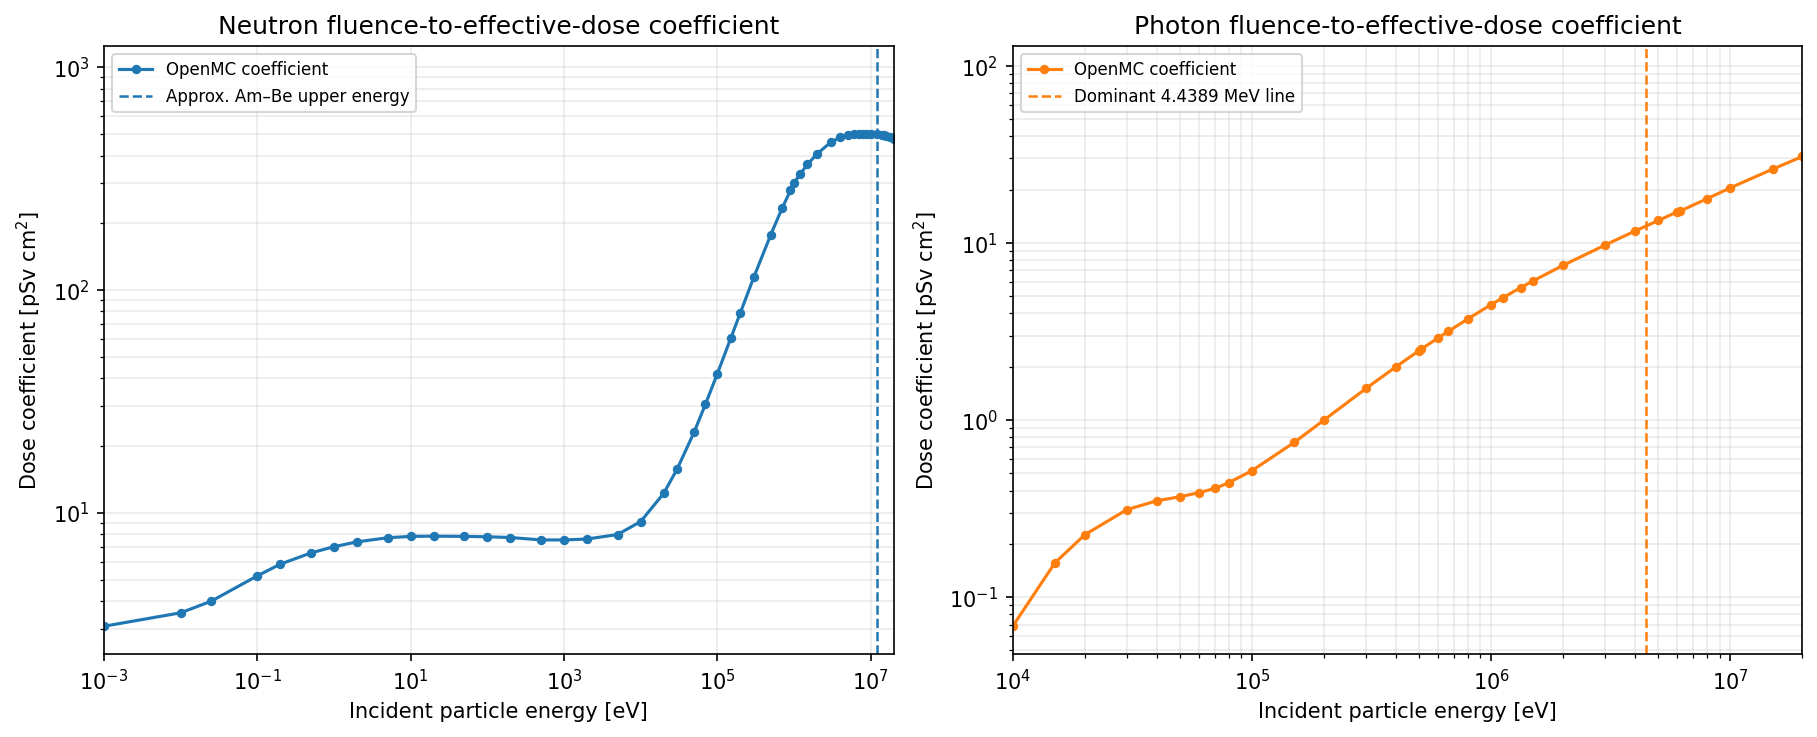

Saved figure: N3_simulated_unified_outputs/figures/section_4_dose_conversion_coefficients.png


In [7]:
AMBE_NEUTRON_MAX_ENERGY_EV = 12.0e6
AMBE_GAMMA_LINE_ENERGY_EV = 4.4389e6

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    dpi=150,
    layout="constrained",
)

coefficient_plot_settings = [
    {
        "ax": axes[0],
        "energies": neutron_dose_energies,
        "coefficients": neutron_dose_coefficients,
        "color": "tab:blue",
        "title": "Neutron fluence-to-effective-dose coefficient",
        "reference_energy": AMBE_NEUTRON_MAX_ENERGY_EV,
        "reference_label": "Approx. Am–Be upper energy",
        "x_limits": (1.0e-3, 2.0e7),
    },
    {
        "ax": axes[1],
        "energies": photon_dose_energies,
        "coefficients": photon_dose_coefficients,
        "color": "tab:orange",
        "title": "Photon fluence-to-effective-dose coefficient",
        "reference_energy": AMBE_GAMMA_LINE_ENERGY_EV,
        "reference_label": "Dominant 4.4389 MeV line",
        "x_limits": (1.0e4, 2.0e7),
    },
]

for settings_dict in coefficient_plot_settings:
    ax = settings_dict["ax"]
    energies = settings_dict["energies"]
    coefficients = settings_dict["coefficients"]

    positive = (
        np.isfinite(energies)
        & np.isfinite(coefficients)
        & (energies > 0.0)
        & (coefficients > 0.0)
    )

    ax.loglog(
        energies[positive],
        coefficients[positive],
        marker="o",
        markersize=3.5,
        linewidth=1.5,
        color=settings_dict["color"],
        label="OpenMC coefficient",
    )

    ax.axvline(
        settings_dict["reference_energy"],
        color=settings_dict["color"],
        linestyle="--",
        linewidth=1.2,
        label=settings_dict["reference_label"],
    )

    ax.set_xlim(*settings_dict["x_limits"])
    ax.set_xlabel("Incident particle energy [eV]")
    ax.set_ylabel(r"Dose coefficient [pSv cm$^2$]")
    ax.set_title(settings_dict["title"])
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8)

coefficient_figure_path = (
    FIGURE_DIR / "section_4_dose_conversion_coefficients.png"
)

fig.savefig(
    coefficient_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {coefficient_figure_path}")


# 5) Build the common-cube flux and dose-rate models

Each model contains two tallies per point in the same one-cell cubic mesh: an
unweighted particle-flux tally and an energy-weighted dose tally. OpenMC source
strengths remain equal to one emitted source particle; physical source rates
are applied only during post-processing.

The neutron production retains its $200\times100000=2.0\times10^7$
source-neutron configuration. The new gamma production uses the photon
weight-window map generated independently in Notebook 2.5. Every gamma dose and
common-flux tally has a 50% relative-error trigger. The configured batch count
is therefore a minimum rather than a fixed total.

In [8]:
def make_dose_mesh_tally(
    name,
    center,
    detector_side_cm,
    particle,
    dose_filter,
):
    """Create a one-cell mesh tally weighted by a dose coefficient."""

    x_cm, y_cm, z_cm = center
    half_side_cm = detector_side_cm / 2.0

    mesh = openmc.RegularMesh()
    mesh.dimension = (1, 1, 1)
    mesh.lower_left = (
        x_cm - half_side_cm,
        y_cm - half_side_cm,
        z_cm - half_side_cm,
    )
    mesh.upper_right = (
        x_cm + half_side_cm,
        y_cm + half_side_cm,
        z_cm + half_side_cm,
    )

    tally = openmc.Tally(name=name)
    tally.filters = [
        openmc.MeshFilter(mesh),
        openmc.ParticleFilter([particle]),
        dose_filter,
    ]
    tally.scores = ["flux"]

    return tally


def make_common_flux_mesh_tally(name, center, detector_side_cm, particle):
    """Create an unweighted one-cell flux tally in the common cube."""

    x_cm, y_cm, z_cm = center
    half_side_cm = detector_side_cm / 2.0
    mesh = openmc.RegularMesh()
    mesh.dimension = (1, 1, 1)
    mesh.lower_left = tuple(v - half_side_cm for v in (x_cm, y_cm, z_cm))
    mesh.upper_right = tuple(v + half_side_cm for v in (x_cm, y_cm, z_cm))

    tally = openmc.Tally(name=name)
    tally.filters = [
        openmc.MeshFilter(mesh),
        openmc.ParticleFilter([particle]),
    ]
    tally.scores = ["flux"]
    return tally


neutron_dose_tally_list = []
gamma_dose_tally_list = []
common_neutron_flux_tally_list = []
common_gamma_flux_tally_list = []

for point_name, point_data in DOSE_SCAN_POINTS.items():
    neutron_dose_tally_list.append(
        make_dose_mesh_tally(
            name=f"neutron_dose_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="neutron",
            dose_filter=neutron_dose_filter,
        )
    )

    gamma_dose_tally_list.append(
        make_dose_mesh_tally(
            name=f"gamma_dose_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="photon",
            dose_filter=photon_dose_filter,
        )
    )

    common_neutron_flux_tally_list.append(
        make_common_flux_mesh_tally(
            name=f"common_neutron_flux_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="neutron",
        )
    )
    common_gamma_flux_tally_list.append(
        make_common_flux_mesh_tally(
            name=f"common_gamma_flux_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="photon",
        )
    )


neutron_dose_tallies = openmc.Tallies(
    neutron_dose_tally_list + common_neutron_flux_tally_list
)
gamma_dose_tallies = openmc.Tallies(
    gamma_dose_tally_list + common_gamma_flux_tally_list
)

NEUTRON_DOSE_TALLY_NAMES = [
    tally.name for tally in neutron_dose_tally_list
]
GAMMA_DOSE_TALLY_NAMES = [
    tally.name for tally in gamma_dose_tally_list
]
COMMON_NEUTRON_FLUX_TALLY_NAMES = [
    tally.name for tally in common_neutron_flux_tally_list
]
COMMON_GAMMA_FLUX_TALLY_NAMES = [
    tally.name for tally in common_gamma_flux_tally_list
]
GAMMA_PRODUCTION_TALLY_NAMES = (
    GAMMA_DOSE_TALLY_NAMES + COMMON_GAMMA_FLUX_TALLY_NAMES
)

if len(NEUTRON_DOSE_TALLY_NAMES) != len(set(NEUTRON_DOSE_TALLY_NAMES)):
    raise ValueError("Neutron dose-tally names are not unique.")

if len(GAMMA_DOSE_TALLY_NAMES) != len(set(GAMMA_DOSE_TALLY_NAMES)):
    raise ValueError("Gamma dose-tally names are not unique.")


NEUTRON_DOSE_RUN_BATCHES = 200
NEUTRON_DOSE_RUN_PARTICLES = 100_000
NEUTRON_DOSE_RUN_SEED = 20260316

GAMMA_DOSE_TARGET_REL_ERR = 0.80
GAMMA_DOSE_MIN_BATCHES = 200
GAMMA_DOSE_MAX_BATCHES = 850
GAMMA_DOSE_PARTICLES_PER_BATCH = 25_000
GAMMA_DOSE_TRIGGER_BATCH_INTERVAL = 20
GAMMA_DOSE_RUN_SEED = 20262317


neutron_dose_settings = ambe_base_model.build_neutron_settings(
    energy_dist=neutron_energy_dist,
    batches=NEUTRON_DOSE_RUN_BATCHES,
    particles=NEUTRON_DOSE_RUN_PARTICLES,
    inactive=0,
    source_strength=1.0,
)
neutron_dose_settings.seed = NEUTRON_DOSE_RUN_SEED


def build_gamma_source(gamma_energy_distribution, source_strength=1.0):
    """Build an isotropic point photon source at the capsule centre."""

    source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=gamma_energy_distribution,
        particle="photon",
    )
    source.strength = float(source_strength)
    return source


gamma_dose_settings = openmc.Settings()
gamma_dose_settings.run_mode = "fixed source"
gamma_dose_settings.source = build_gamma_source(
    gamma_energy_distribution=gamma_energy_dist,
    source_strength=1.0,
)
gamma_dose_settings.batches = GAMMA_DOSE_MIN_BATCHES
gamma_dose_settings.particles = GAMMA_DOSE_PARTICLES_PER_BATCH
gamma_dose_settings.inactive = 0
gamma_dose_settings.seed = GAMMA_DOSE_RUN_SEED
gamma_dose_settings.photon_transport = True
gamma_dose_settings.trigger_active = True
gamma_dose_settings.trigger_max_batches = GAMMA_DOSE_MAX_BATCHES
gamma_dose_settings.trigger_batch_interval = (
    GAMMA_DOSE_TRIGGER_BATCH_INTERVAL
)

for tally in gamma_dose_tallies:
    trigger = openmc.Trigger(
        trigger_type="rel_err",
        threshold=GAMMA_DOSE_TARGET_REL_ERR,
        ignore_zeros=False,
    )
    trigger.scores = ["flux"]
    tally.triggers = [trigger]


neutron_dose_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=neutron_dose_settings,
    tallies=neutron_dose_tallies,
)

gamma_dose_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=gamma_dose_settings,
    tallies=gamma_dose_tallies,
)


print("Dose-rate models created.")
print(f"Neutron tallies: {len(neutron_dose_tally_list)}")
print(f"Gamma tallies:   {len(gamma_dose_tally_list)}")
print(f"Common neutron-flux tallies: {len(common_neutron_flux_tally_list)}")
print(f"Common gamma-flux tallies:   {len(common_gamma_flux_tally_list)}")
print(
    "Configured source neutrons: "
    f"{NEUTRON_DOSE_RUN_BATCHES * NEUTRON_DOSE_RUN_PARTICLES:.3e}"
)
print(
    "Gamma source photons at minimum batches: "
    f"{GAMMA_DOSE_MIN_BATCHES * GAMMA_DOSE_PARTICLES_PER_BATCH:.3e}"
)
print(
    "Gamma source photons at maximum batches: "
    f"{GAMMA_DOSE_MAX_BATCHES * GAMMA_DOSE_PARTICLES_PER_BATCH:.3e}"
)
print(f"Gamma relative-error target: {100.0 * GAMMA_DOSE_TARGET_REL_ERR:.1f}%")


Dose-rate models created.
Neutron tallies: 61
Gamma tallies:   61
Common neutron-flux tallies: 61
Common gamma-flux tallies:   61
Configured source neutrons: 2.000e+07
Gamma source photons at minimum batches: 5.000e+06
Gamma source photons at maximum batches: 2.125e+07
Gamma relative-error target: 80.0%


# 6) Run the common-cube neutron and variance-reduced gamma models

The common-cube flux and AP-dose tallies are new, so both particle models must
be run once. The gamma model loads the existing `weight_windows.h5` generated
by Notebook 2.5 and performs a statistically independent production run in a
new directory. Failure of Notebook 2.5's later production calculation to meet
10% does not invalidate this weight-window map.

For the first execution of this revised Notebook 3, use:

```python
RERUN_NEUTRON_DOSE = True
RUN_GAMMA_DOSE_PRODUCTION = True
ENFORCE_GAMMA_DOSE_TARGET = True
```

After both new statepoints exist and the audit confirms that all 122 gamma dose
and common-flux tallies are at or below 50%, change the two run flags to
`False`. Later executions then reuse the statepoints. Notebook 2.5's LND 712
statepoint is represented through its exported flux table; its spatial photon
weight-window map is reused directly.

In [9]:
RERUN_NEUTRON_DOSE = True
RUN_GAMMA_DOSE_PRODUCTION = True
ENFORCE_GAMMA_DOSE_TARGET = True

NEUTRON_DOSE_RUN_DIR = Path("openmc_run_neutron_common_flux_and_dose")
GAMMA_DOSE_RUN_DIR = Path("openmc_run_gamma_common_flux_and_dose_ww")

DEFAULT_NOTEBOOK_2_5_WEIGHT_WINDOWS_PATH = Path(
    "openmc_run_measurement_gamma_scan_lnd712_cellfilter_"
    "group_1_ww_generation/weight_windows.h5"
)

GROUP_1_WEIGHT_WINDOWS_PATH = find_first_existing_file(
    [
        GROUP_1_WEIGHT_WINDOW_FILE_FROM_METADATA,
        DEFAULT_NOTEBOOK_2_5_WEIGHT_WINDOWS_PATH,
    ],
    "Notebook 2.5 photon weight-window file",
).resolve()

gamma_dose_settings.weight_window_checkpoints = {
    "collision": True,
    "surface": True,
}
gamma_dose_settings.survival_biasing = False
gamma_dose_settings.weight_windows_file = GROUP_1_WEIGHT_WINDOWS_PATH
gamma_dose_settings.weight_windows_on = True
gamma_dose_model.settings = gamma_dose_settings


def statepoint_batch_number(path):
    match = re.search(r"statepoint\.(\d+)\.h5$", Path(path).name)
    return int(match.group(1)) if match else -1


def normalize_run_statepoint(run_result, run_directory):
    """Resolve the statepoint path returned by openmc.Model.run."""

    statepoint_path = Path(run_result)

    if not statepoint_path.is_absolute() and not statepoint_path.exists():
        candidate = Path(run_directory) / statepoint_path
        if candidate.exists():
            statepoint_path = candidate

    return statepoint_path.resolve()


def run_model_and_resolve_statepoint(model, run_directory, label):
    run_directory = Path(run_directory)
    run_directory.mkdir(parents=True, exist_ok=True)
    model.export_to_xml(directory=run_directory)

    print(f"Running {label} simulation in {run_directory.resolve()} ...")
    run_result = model.run(cwd=run_directory)
    statepoint_path = normalize_run_statepoint(
        run_result=run_result,
        run_directory=run_directory,
    )

    if not statepoint_path.exists():
        raise FileNotFoundError(
            f"OpenMC did not produce the expected statepoint: {statepoint_path}"
        )

    return statepoint_path


def find_latest_statepoint(run_directory):
    candidates = list(Path(run_directory).glob("statepoint.*.h5"))
    if not candidates:
        raise FileNotFoundError(
            f"No statepoint was found in '{run_directory}'."
        )
    return max(
        candidates,
        key=lambda path: path.stat().st_mtime_ns,
    ).resolve()


def run_or_reuse_statepoint(
    model,
    run_directory,
    batches,
    rerun,
    label,
):
    """Run a model or reuse the exact statepoint for its batch count."""

    run_directory = Path(run_directory)
    expected_statepoint = run_directory / f"statepoint.{batches}.h5"

    if rerun:
        return run_model_and_resolve_statepoint(
            model=model,
            run_directory=run_directory,
            label=label,
        )

    if expected_statepoint.exists():
        print(f"Reusing {label} statepoint: {expected_statepoint}")
        return expected_statepoint

    available_statepoints = sorted(run_directory.glob("statepoint.*.h5"))
    available_text = (
        ", ".join(str(path) for path in available_statepoints)
        if available_statepoints
        else "none"
    )

    raise FileNotFoundError(
        f"Expected {label} statepoint {expected_statepoint} was not found. "
        f"Available statepoints: {available_text}. Set the corresponding "
        "RERUN flag to True to run the configured model."
    )


sp_path_neutron_dose = run_or_reuse_statepoint(
    model=neutron_dose_model,
    run_directory=NEUTRON_DOSE_RUN_DIR,
    batches=NEUTRON_DOSE_RUN_BATCHES,
    rerun=RERUN_NEUTRON_DOSE,
    label="neutron dose-rate",
)

if RUN_GAMMA_DOSE_PRODUCTION:
    sp_path_gamma_dose = run_model_and_resolve_statepoint(
        model=gamma_dose_model,
        run_directory=GAMMA_DOSE_RUN_DIR,
        label="variance-reduced gamma dose-rate",
    )
else:
    sp_path_gamma_dose = find_latest_statepoint(GAMMA_DOSE_RUN_DIR)
    print(
        "Reusing variance-reduced gamma dose-rate statepoint: "
        f"{sp_path_gamma_dose}"
    )


def audit_relative_errors(statepoint_path, tally_names, target_rel_err):
    """Return one row per scalar tally and its statepoint relative error."""

    audit_rows = []

    with openmc.StatePoint(statepoint_path) as statepoint:
        available_tallies = {
            tally.name for tally in statepoint.tallies.values()
        }
        missing_tallies = sorted(set(tally_names) - available_tallies)
        if missing_tallies:
            raise KeyError(
                "Gamma-dose statepoint lacks expected tallies: "
                + ", ".join(missing_tallies[:10])
            )

        for tally_name in tally_names:
            tally = statepoint.get_tally(name=tally_name)
            mean = np.asarray(tally.mean, dtype=float).ravel()
            std_dev = np.asarray(tally.std_dev, dtype=float).ravel()

            if mean.size != 1 or std_dev.size != 1:
                raise ValueError(
                    f"Trigger-audit tally '{tally_name}' is not scalar."
                )

            mean_value = float(mean[0])
            std_dev_value = float(std_dev[0])
            if mean_value == 0.0 or not np.isfinite(mean_value):
                relative_error = np.inf
            else:
                relative_error = abs(std_dev_value / mean_value)

            audit_rows.append({
                "tally_name": tally_name,
                "mean_per_source": mean_value,
                "std_dev_per_source": std_dev_value,
                "relative_error": relative_error,
                "relative_error_percent": 100.0 * relative_error,
                "target_reached": (
                    np.isfinite(relative_error)
                    and relative_error <= target_rel_err
                ),
            })

    return pd.DataFrame(audit_rows)


GAMMA_DOSE_TRIGGER_AUDIT_DF = audit_relative_errors(
    statepoint_path=sp_path_gamma_dose,
    tally_names=GAMMA_PRODUCTION_TALLY_NAMES,
    target_rel_err=GAMMA_DOSE_TARGET_REL_ERR,
)

GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED = statepoint_batch_number(
    sp_path_gamma_dose
)
GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT = float(
    GAMMA_DOSE_TRIGGER_AUDIT_DF["relative_error_percent"].max()
)
GAMMA_DOSE_TARGET_REACHED = bool(
    GAMMA_DOSE_TRIGGER_AUDIT_DF["target_reached"].all()
)

print()
print("Gamma-dose production audit:")
print(f"  Completed batches: {GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED}")
print(
    "  Maximum relative uncertainty: "
    f"{GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
)
print(f"  All 122 dose/flux tallies reached target: {GAMMA_DOSE_TARGET_REACHED}")

display(
    GAMMA_DOSE_TRIGGER_AUDIT_DF.sort_values(
        "relative_error_percent",
        ascending=False,
    ).head(10)
)

if ENFORCE_GAMMA_DOSE_TARGET and not GAMMA_DOSE_TARGET_REACHED:
    raise RuntimeError(
        "The gamma-dose run reached its maximum allowed batches before "
        f"all 122 dose/flux tallies met the {100.0 * GAMMA_DOSE_TARGET_REL_ERR:.1f}% "
        "target. Increase GAMMA_DOSE_MAX_BATCHES and rerun only the gamma "
        "dose production; the neutron-dose statepoint remains reusable."
    )


Found Notebook 2.5 photon weight-window file: openmc_run_measurement_gamma_scan_lnd712_cellfilter_group_1_ww_generation/weight_windows.h5
Running neutron dose-rate simulation in /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_neutron_common_flux_and_dose ...


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=4.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=6.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

,tally_name,mean_per_source,std_dev_per_source,relative_error,relative_error_percent,target_reached
23,gamma_dose_P2_x420_h55,6.120556e-08,4.148887e-08,0.677861,67.786114,True
6,gamma_dose_P1_x320_h42,2.561040e-06,1.682716e-06,0.657044,65.704395,True
15,gamma_dose_P1_x320_h85,2.879270e-06,1.832950e-06,0.636603,63.660256,True
7,gamma_dose_P1_x420_h42,2.325780e-06,1.471265e-06,0.632590,63.258974,True
16,gamma_dose_P1_x420_h85,3.085756e-06,1.831727e-06,0.593607,59.360711,True
51,gamma_dose_P3_x400_h85,1.164722e-07,6.804493e-08,0.584216,58.421604,True
67,common_gamma_flux_P1_x320_h42,3.353133e-07,1.889261e-07,0.563432,56.343152,True
68,common_gamma_flux_P1_x420_h42,2.949646e-07,1.602584e-07,0.543314,54.331389,True
20,gamma_dose_P2_x176_h55,9.594646e-07,5.210493e-07,0.543063,54.306259,True
28,gamma_dose_P2_x114_h85,1.382507e-06,7.164013e-07,0.518190,51.819018,True


# 7) Post-process the neutron and gamma dose tallies

The mesh tally is divided by its $8\ \mathrm{cm^3}$ averaging volume, scaled by
the relevant physical emission rate, and converted from
$\mathrm{pSv\,s^{-1}}$ to $\mu\mathrm{Sv\,h^{-1}}$.

The new photon statepoint has passed Notebook 3's mandatory 50% audit for all
122 gamma dose and common-flux tallies. The neutron statepoint retains the
precision produced by its fixed-history calculation.

The uncertainty classes remain stricter than the production stop criterion:

- low: $u_{\mathrm{rel,MC}}<5\%$;
- moderate: $5\%\leq u_{\mathrm{rel,MC}}<10\%$;
- high: $10\%\leq u_{\mathrm{rel,MC}}<25\%$;
- very high: $u_{\mathrm{rel,MC}}\geq25\%$.

Thus, a tally may satisfy the 50% production criterion and still be classified
as having very high uncertainty. Such points are retained for traceability and
should be interpreted as approximate magnitudes rather than precise local
variations.

In [10]:
def get_scalar_tally_mean_std(statepoint, tally_name):
    """Return a scalar tally mean and OpenMC batch standard deviation."""

    tally = statepoint.get_tally(name=tally_name)
    mean = np.asarray(tally.mean, dtype=float).flatten()
    standard_deviation = np.asarray(
        tally.std_dev,
        dtype=float,
    ).flatten()

    if mean.size != 1 or standard_deviation.size != 1:
        raise ValueError(
            f"Tally '{tally_name}' is not scalar. "
            f"Mean size: {mean.size}; standard-deviation size: "
            f"{standard_deviation.size}."
        )

    return float(mean[0]), float(standard_deviation[0])


def postprocess_dose_tallies(
    statepoint_path,
    scan_points,
    tally_prefix,
    expected_tally_names,
    source_strength,
    particle_label,
):
    """Convert energy-weighted mesh tallies to physical dose rates."""

    rows = []

    with openmc.StatePoint(statepoint_path) as statepoint:
        available_tally_names = {
            tally.name for tally in statepoint.tallies.values()
        }

        missing_tallies = sorted(
            set(expected_tally_names) - available_tally_names
        )

        if missing_tallies:
            raise LookupError(
                f"Statepoint {statepoint_path} does not contain all expected "
                f"{particle_label} dose tallies. First missing tallies: "
                + ", ".join(missing_tallies[:5])
            )

        for point_name, point_data in scan_points.items():
            tally_name = f"{tally_prefix}_{point_name}"
            mean_raw, u_mc_raw = get_scalar_tally_mean_std(
                statepoint,
                tally_name,
            )

            dose_per_source_pSv = (
                mean_raw / DOSE_SCAN_DET_VOLUME
            )
            u_mc_per_source_pSv = (
                u_mc_raw / DOSE_SCAN_DET_VOLUME
            )

            dose_rate_uSv_h = (
                dose_per_source_pSv
                * source_strength
                * PSV_PER_S_TO_USV_PER_H
            )
            u_mc_dose_rate_uSv_h = (
                u_mc_per_source_pSv
                * source_strength
                * PSV_PER_S_TO_USV_PER_H
            )

            if dose_rate_uSv_h > 0.0:
                rel_u_mc_percent = (
                    100.0
                    * u_mc_dose_rate_uSv_h
                    / dose_rate_uSv_h
                )
            else:
                rel_u_mc_percent = np.nan

            x_cm, y_cm, z_cm = point_data["center"]

            rows.append({
                "position": point_data["position"],
                "point_name": point_name,
                "distance_cm": point_data["distance_cm"],
                "height_cm": point_data["height_cm"],
                "common_dose_x_cm": x_cm,
                "common_dose_y_cm": y_cm,
                "common_dose_z_cm": z_cm,
                "tally_name": tally_name,
                "detector_volume_cm3": DOSE_SCAN_DET_VOLUME,
                f"{particle_label}_dose_per_source [pSv/source]": (
                    dose_per_source_pSv
                ),
                f"u_mc_{particle_label}_dose_per_source [pSv/source]": (
                    u_mc_per_source_pSv
                ),
                f"{particle_label}_dose_rate [uSv/h]": (
                    dose_rate_uSv_h
                ),
                f"u_mc_{particle_label}_dose_rate [uSv/h]": (
                    u_mc_dose_rate_uSv_h
                ),
                f"rel_u_mc_{particle_label}_dose_rate [%]": (
                    rel_u_mc_percent
                ),
                f"{particle_label}_dose_mc_uncertainty_class": (
                    classify_relative_mc_uncertainty(
                        rel_u_mc_percent
                    )
                ),
            })

    dataframe = pd.DataFrame(rows)
    dataframe = dataframe.sort_values(
        ["position", "height_cm", "distance_cm"]
    ).reset_index(drop=True)

    return dataframe


def postprocess_common_flux_tallies(
    statepoint_path,
    scan_points,
    tally_prefix,
    expected_tally_names,
    source_strength,
    particle_label,
    flux_unit,
):
    """Convert common-cube track-length tallies to physical flux."""

    rows = []
    with openmc.StatePoint(statepoint_path) as statepoint:
        available = {tally.name for tally in statepoint.tallies.values()}
        missing = sorted(set(expected_tally_names) - available)
        if missing:
            raise LookupError(
                f"Statepoint {statepoint_path} lacks common {particle_label} "
                "flux tallies: " + ", ".join(missing[:5])
            )

        for point_name, point_data in scan_points.items():
            tally_name = f"{tally_prefix}_{point_name}"
            mean_raw, u_raw = get_scalar_tally_mean_std(statepoint, tally_name)
            flux = mean_raw / DOSE_SCAN_DET_VOLUME * source_strength
            u_flux = u_raw / DOSE_SCAN_DET_VOLUME * source_strength
            rel_u = 100.0 * u_flux / flux if flux > 0.0 else np.nan
            x_cm, y_cm, z_cm = point_data["center"]
            rows.append({
                "point_name": point_name,
                "common_flux_x_cm": x_cm,
                "common_flux_y_cm": y_cm,
                "common_flux_z_cm": z_cm,
                "common_flux_tally_volume_cm3": DOSE_SCAN_DET_VOLUME,
                f"common_{particle_label}_flux [{flux_unit}]": flux,
                f"u_mc_common_{particle_label}_flux [{flux_unit}]": u_flux,
                f"rel_u_mc_common_{particle_label}_flux [%]": rel_u,
            })
    return pd.DataFrame(rows)


neutron_dose_df = postprocess_dose_tallies(
    statepoint_path=sp_path_neutron_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="neutron_dose",
    expected_tally_names=NEUTRON_DOSE_TALLY_NAMES,
    source_strength=SOURCE_NEUTRON_EMISSION,
    particle_label="neutron",
)

gamma_dose_df = postprocess_dose_tallies(
    statepoint_path=sp_path_gamma_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="gamma_dose",
    expected_tally_names=GAMMA_DOSE_TALLY_NAMES,
    source_strength=GAMMA_SOURCE_EMISSION,
    particle_label="gamma",
)

common_neutron_flux_df = postprocess_common_flux_tallies(
    statepoint_path=sp_path_neutron_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="common_neutron_flux",
    expected_tally_names=COMMON_NEUTRON_FLUX_TALLY_NAMES,
    source_strength=SOURCE_NEUTRON_EMISSION,
    particle_label="neutron",
    flux_unit="n/cm2/s",
)

common_gamma_flux_df = postprocess_common_flux_tallies(
    statepoint_path=sp_path_gamma_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="common_gamma_flux",
    expected_tally_names=COMMON_GAMMA_FLUX_TALLY_NAMES,
    source_strength=GAMMA_SOURCE_EMISSION,
    particle_label="gamma",
    flux_unit="photon/cm2/s",
)


print("Dose-rate post-processing complete.")
print(f"Neutron points: {len(neutron_dose_df)}")
print(f"Gamma points:   {len(gamma_dose_df)}")
print(f"Common neutron-flux points: {len(common_neutron_flux_df)}")
print(f"Common gamma-flux points:   {len(common_gamma_flux_df)}")

display(
    neutron_dose_df
    .groupby(["position", "neutron_dose_mc_uncertainty_class"])
    .size()
    .rename("count")
    .reset_index()
)

display(
    gamma_dose_df
    .groupby(["position", "gamma_dose_mc_uncertainty_class"])
    .size()
    .rename("count")
    .reset_index()
)


Dose-rate post-processing complete.
Neutron points: 61
Gamma points:   61
Common neutron-flux points: 61
Common gamma-flux points:   61


,position,neutron_dose_mc_uncertainty_class,count
0,P1,high,5
1,P1,low,2
2,P1,moderate,5
3,P1,very high,5
4,P2,high,10
5,P2,moderate,1
6,P2,very high,6
7,P3,high,6
8,P3,low,1
9,P3,moderate,3


,position,gamma_dose_mc_uncertainty_class,count
0,P1,high,7
1,P1,moderate,2
2,P1,very high,8
3,P2,high,6
4,P2,very high,11
5,P3,high,7
6,P3,moderate,1
7,P3,very high,10
8,P4,high,4
9,P4,very high,1


# 8) Merge flux and dose results

All four component tables are merged one-to-one by `point_name`. The final
table keeps the detector-specific `neutron_flux_*` and `gamma_flux_*` results
separate from the new `common_*_flux` results. Only the latter are co-located
and volume matched, so only they are used for the gamma-to-neutron flux ratio.

Only the two dose-rate components evaluated in the identical common cubes are
added:

$$
\dot H_{\mathrm{tot}}=\dot H_n+\dot H_\gamma.
$$

The total MC standard uncertainty is propagated from the independent neutron
and gamma transport runs as

$$
u_{\mathrm{MC}}(\dot H_{\mathrm{tot}})
=
\sqrt{
u_{\mathrm{MC}}^2(\dot H_n)
+
u_{\mathrm{MC}}^2(\dot H_\gamma)
}.
$$

This independence assumption applies to the Monte Carlo estimators. It does not
turn the result into a complete physical simulation-uncertainty budget.


In [11]:
neutron_dose_keep = neutron_dose_df[
    [
        "point_name",
        "common_dose_x_cm",
        "common_dose_y_cm",
        "common_dose_z_cm",
        "neutron_dose_per_source [pSv/source]",
        "u_mc_neutron_dose_per_source [pSv/source]",
        "neutron_dose_rate [uSv/h]",
        "u_mc_neutron_dose_rate [uSv/h]",
        "rel_u_mc_neutron_dose_rate [%]",
        "neutron_dose_mc_uncertainty_class",
    ]
].copy()

gamma_dose_keep = gamma_dose_df[
    [
        "point_name",
        "gamma_dose_per_source [pSv/source]",
        "u_mc_gamma_dose_per_source [pSv/source]",
        "gamma_dose_rate [uSv/h]",
        "u_mc_gamma_dose_rate [uSv/h]",
        "rel_u_mc_gamma_dose_rate [%]",
        "gamma_dose_mc_uncertainty_class",
    ]
].copy()

gamma_flux_keep = gamma_flux_df[
    [
        "point_name",
        "gamma_flux_x_cm",
        "gamma_flux_y_cm",
        "gamma_flux_z_cm",
        "gamma_flux_tally_volume_cm3",
        "gamma_flux [photon/cm2/s]",
        "u_mc_gamma_flux [photon/cm2/s]",
        "rel_u_mc_gamma_flux [%]",
    ]
].copy()


unified_df = neutron_flux_df.merge(
    gamma_flux_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    neutron_dose_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    gamma_dose_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    common_neutron_flux_df,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

common_gamma_flux_keep = common_gamma_flux_df.drop(
    columns=[
        "common_flux_x_cm",
        "common_flux_y_cm",
        "common_flux_z_cm",
        "common_flux_tally_volume_cm3",
    ]
)
unified_df = unified_df.merge(
    common_gamma_flux_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)

if len(unified_df) != 61:
    raise ValueError(
        "The unified table must contain 61 points; "
        f"found {len(unified_df)}."
    )


# Explicit coordinate aliases retained for the later comparison notebook.
# They always mean the common dose-reference cube, never the LND 712 centre.
unified_df["x_cm"] = unified_df["common_dose_x_cm"]
unified_df["y_cm"] = unified_df["common_dose_y_cm"]
unified_df["z_cm"] = unified_df["common_dose_z_cm"]

for axis in ["x", "y", "z"]:
    common_vs_neutron = np.abs(
        unified_df[f"common_dose_{axis}_cm"].astype(float)
        - unified_df[f"neutron_flux_{axis}_cm"].astype(float)
    )
    if np.nanmax(common_vs_neutron) > 1.0e-12:
        raise ValueError(
            "Common dose coordinates must equal the Notebook 2 neutron "
            f"coordinates; mismatch found in {axis}."
        )

unified_df["flux_centre_separation_cm"] = np.sqrt(
    sum(
        (
            unified_df[f"gamma_flux_{axis}_cm"].astype(float)
            - unified_df[f"neutron_flux_{axis}_cm"].astype(float)
        )**2
        for axis in ["x", "y", "z"]
    )
)


# ------------------------------------------------------------
# Total dose rate and MC uncertainty
# ------------------------------------------------------------

unified_df["total_dose_rate [uSv/h]"] = (
    unified_df["neutron_dose_rate [uSv/h]"]
    + unified_df["gamma_dose_rate [uSv/h]"]
)

unified_df["u_mc_total_dose_rate [uSv/h]"] = np.sqrt(
    unified_df["u_mc_neutron_dose_rate [uSv/h]"]**2
    + unified_df["u_mc_gamma_dose_rate [uSv/h]"]**2
)

unified_df["rel_u_mc_total_dose_rate [%]"] = np.where(
    unified_df["total_dose_rate [uSv/h]"] > 0.0,
    100.0
    * unified_df["u_mc_total_dose_rate [uSv/h]"]
    / unified_df["total_dose_rate [uSv/h]"],
    np.nan,
)

unified_df["total_dose_mc_uncertainty_class"] = pd.Categorical(
    unified_df["rel_u_mc_total_dose_rate [%]"].apply(
        classify_relative_mc_uncertainty
    ),
    categories=MC_UNCERTAINTY_ORDER,
    ordered=True,
)


# Compatibility aliases retained for the later comparison notebook.
# The u_mc_* columns above are the authoritative current names.
unified_df["neutron_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_neutron_dose_rate [uSv/h]"]
)
unified_df["gamma_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_gamma_dose_rate [uSv/h]"]
)
unified_df["total_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_total_dose_rate [uSv/h]"]
)
unified_df["neutron_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_neutron_dose_rate [%]"]
)
unified_df["gamma_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_gamma_dose_rate [%]"]
)
unified_df["total_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_total_dose_rate [%]"]
)
unified_df["neutron_flux_std [n/cm2/s]"] = (
    unified_df["u_mc_neutron_flux [n/cm2/s]"]
)
unified_df["gamma_flux_std [photon/cm2/s]"] = (
    unified_df["u_mc_gamma_flux [photon/cm2/s]"]
)
unified_df["neutron_flux_rel_unc [%]"] = (
    unified_df["rel_u_mc_neutron_flux [%]"]
)
unified_df["gamma_flux_rel_unc [%]"] = (
    unified_df["rel_u_mc_gamma_flux [%]"]
)


# ------------------------------------------------------------
# Ratios and dose fractions
# ------------------------------------------------------------

common_neutron_flux = unified_df[
    "common_neutron_flux [n/cm2/s]"
].to_numpy(dtype=float)
common_gamma_flux = unified_df[
    "common_gamma_flux [photon/cm2/s]"
].to_numpy(dtype=float)
u_common_neutron_flux = unified_df[
    "u_mc_common_neutron_flux [n/cm2/s]"
].to_numpy(dtype=float)
u_common_gamma_flux = unified_df[
    "u_mc_common_gamma_flux [photon/cm2/s]"
].to_numpy(dtype=float)

unified_df["common_gamma_to_neutron_flux_ratio"] = np.divide(
    common_gamma_flux,
    common_neutron_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_neutron_flux > 0.0,
)
unified_df["common_total_particle_flux [particles/cm2/s]"] = (
    common_neutron_flux + common_gamma_flux
)
unified_df["u_mc_common_total_particle_flux [particles/cm2/s]"] = np.sqrt(
    u_common_neutron_flux**2 + u_common_gamma_flux**2
)

valid_flux_ratio = (common_neutron_flux > 0.0) & (common_gamma_flux > 0.0)
flux_ratio_relative_variance = np.divide(
    u_common_gamma_flux,
    common_gamma_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_gamma_flux > 0.0,
)**2 + np.divide(
    u_common_neutron_flux,
    common_neutron_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_neutron_flux > 0.0,
)**2
unified_df["u_mc_common_gamma_to_neutron_flux_ratio"] = np.where(
    valid_flux_ratio,
    unified_df["common_gamma_to_neutron_flux_ratio"]
    * np.sqrt(flux_ratio_relative_variance),
    np.nan,
)

neutron_rate = unified_df["neutron_dose_rate [uSv/h]"].to_numpy(dtype=float)
gamma_rate = unified_df["gamma_dose_rate [uSv/h]"].to_numpy(dtype=float)
total_rate = unified_df["total_dose_rate [uSv/h]"].to_numpy(dtype=float)

unified_df["gamma_to_neutron_dose_ratio"] = np.divide(
    gamma_rate,
    neutron_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=neutron_rate > 0.0,
)

unified_df["neutron_dose_fraction"] = np.divide(
    neutron_rate,
    total_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=total_rate > 0.0,
)

unified_df["gamma_dose_fraction"] = np.divide(
    gamma_rate,
    total_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=total_rate > 0.0,
)


# MC uncertainty of gamma/neutron dose ratio for independent tallies.
u_neutron_rate = unified_df[
    "u_mc_neutron_dose_rate [uSv/h]"
].to_numpy(dtype=float)
u_gamma_rate = unified_df[
    "u_mc_gamma_dose_rate [uSv/h]"
].to_numpy(dtype=float)

valid_ratio = (neutron_rate > 0.0) & (gamma_rate > 0.0)

relative_u_gamma = np.divide(
    u_gamma_rate,
    gamma_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=gamma_rate > 0.0,
)
relative_u_neutron = np.divide(
    u_neutron_rate,
    neutron_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=neutron_rate > 0.0,
)

relative_ratio_variance = (
    relative_u_gamma**2 + relative_u_neutron**2
)

unified_df["u_mc_gamma_to_neutron_dose_ratio"] = np.where(
    valid_ratio,
    unified_df["gamma_to_neutron_dose_ratio"].to_numpy(dtype=float)
    * np.sqrt(relative_ratio_variance),
    np.nan,
)


# MC uncertainty of either two-component fraction.
inverse_total_squared = np.divide(
    1.0,
    total_rate**2,
    out=np.zeros(len(unified_df), dtype=float),
    where=total_rate > 0.0,
)

fraction_variance = (
    (gamma_rate * inverse_total_squared)**2 * u_neutron_rate**2
    + (neutron_rate * inverse_total_squared)**2 * u_gamma_rate**2
)

unified_df["u_mc_neutron_dose_fraction"] = np.where(
    total_rate > 0.0,
    np.sqrt(fraction_variance),
    np.nan,
)

unified_df["u_mc_gamma_dose_fraction"] = (
    unified_df["u_mc_neutron_dose_fraction"]
)


unique_heights = np.sort(unified_df["height_cm"].dropna().unique())
if unique_heights.size < 2:
    raise ValueError("At least two unique heights are required for grouping.")
height_gaps = np.diff(unique_heights)
largest_gap_index = int(np.argmax(height_gaps))
HEIGHT_GROUP_BOUNDARY_CM = float(
    0.5 * (unique_heights[largest_gap_index] + unique_heights[largest_gap_index + 1])
)
LOWER_HEIGHT_LABEL = (
    f"Lower height group ({unique_heights.min():g}–"
    f"{unique_heights[largest_gap_index]:g} cm)"
)
UPPER_HEIGHT_LABEL = (
    f"Upper height group ({unique_heights[largest_gap_index + 1]:g}–"
    f"{unique_heights.max():g} cm)"
)


def assign_height_group(height_cm):
    return (
        LOWER_HEIGHT_LABEL
        if float(height_cm) < HEIGHT_GROUP_BOUNDARY_CM
        else UPPER_HEIGHT_LABEL
    )


unified_df["height_group"] = unified_df["height_cm"].apply(
    assign_height_group
)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

dose_fraction_sum = (
    unified_df["neutron_dose_fraction"]
    + unified_df["gamma_dose_fraction"]
)

finite_fraction_sum = np.isfinite(dose_fraction_sum)

if not np.allclose(
    dose_fraction_sum[finite_fraction_sum],
    1.0,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError("Neutron and gamma dose fractions do not sum to one.")

required_result_columns = [
    "neutron_flux [n/cm2/s]",
    "gamma_flux [photon/cm2/s]",
    "neutron_dose_rate [uSv/h]",
    "gamma_dose_rate [uSv/h]",
    "total_dose_rate [uSv/h]",
    "common_neutron_flux [n/cm2/s]",
    "common_gamma_flux [photon/cm2/s]",
    "common_gamma_to_neutron_flux_ratio",
]

if unified_df[required_result_columns].isna().any().any():
    missing_counts = (
        unified_df[required_result_columns]
        .isna()
        .sum()
    )
    raise ValueError(
        "The unified table contains missing core results:\n"
        + missing_counts.to_string()
    )


print("Unified radiation-field table created and validated.")
print(f"Rows:    {len(unified_df)}")
print(f"Columns: {len(unified_df.columns)}")

display(
    unified_df[
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "neutron_flux_x_cm",
            "gamma_flux_x_cm",
            "common_dose_x_cm",
            "neutron_dose_rate [uSv/h]",
            "gamma_dose_rate [uSv/h]",
            "total_dose_rate [uSv/h]",
            "rel_u_mc_total_dose_rate [%]",
            "total_dose_mc_uncertainty_class",
            "neutron_dose_fraction",
            "gamma_dose_fraction",
        ]
    ].head(10)
)


Unified radiation-field table created and validated.
Rows:    61
Columns: 72


,position,point_name,distance_cm,height_cm,neutron_flux_x_cm,gamma_flux_x_cm,common_dose_x_cm,neutron_dose_rate [uSv/h],gamma_dose_rate [uSv/h],total_dose_rate [uSv/h],rel_u_mc_total_dose_rate [%],total_dose_mc_uncertainty_class,neutron_dose_fraction,gamma_dose_fraction
0,P1,P1_x0_h42,0.0,42.0,0.0,0.0,0.0,121.499498,0.959521,122.459019,3.256040,low,0.992165,0.007835
1,P1,P1_x4_h42,4.0,42.0,0.0,0.0,0.0,104.259807,0.774171,105.033978,3.296360,low,0.992629,0.007371
2,P1,P1_x57_h42,57.0,42.0,0.0,0.0,0.0,18.852181,0.164667,19.016847,8.955024,moderate,0.991341,0.008659
3,P1,P1_x114_h42,114.0,42.0,0.0,0.0,0.0,6.968977,0.078633,7.047610,14.051596,high,0.988843,0.011157
4,P1,P1_x176_h42,176.0,42.0,0.0,0.0,0.0,3.581317,0.019664,3.600981,19.623192,high,0.994539,0.005461
5,P1,P1_x199_h42,199.0,42.0,0.0,0.0,0.0,2.047651,0.010100,2.057752,27.346432,very high,0.995092,0.004908
6,P1,P1_x320_h42,320.0,42.0,0.0,0.0,0.0,1.749886,0.008222,1.758108,29.882246,very high,0.995323,0.004677
7,P1,P1_x420_h42,420.0,42.0,0.0,0.0,0.0,0.195611,0.007467,0.203078,90.659672,very high,0.963232,0.036768
8,P1,P1_x0_h85,0.0,85.0,0.0,0.0,0.0,33.574879,0.114549,33.689427,5.737365,moderate,0.996600,0.003400
9,P1,P1_x4_h85,4.0,85.0,0.0,0.0,0.0,33.277250,0.130510,33.407760,6.030612,moderate,0.996093,0.003907


## 8.1) Validation and descriptive summaries

Dose rates and fluxes at different spatial points are not summed. Such a sum
would depend on the chosen sampling grid and would not represent a local field
quantity. The summaries below therefore report point counts, ranges, and
medians for validation and interpretation.


In [12]:
position_summary_df = (
    unified_df
    .groupby("position", observed=True)
    .agg(
        number_of_points=("point_name", "size"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
        median_neutron_dose_rate_uSv_h=(
            "neutron_dose_rate [uSv/h]",
            "median",
        ),
        median_gamma_dose_rate_uSv_h=(
            "gamma_dose_rate [uSv/h]",
            "median",
        ),
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        minimum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "min",
        ),
        maximum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "max",
        ),
        median_gamma_dose_fraction=(
            "gamma_dose_fraction",
            "median",
        ),
        median_rel_u_mc_total_percent=(
            "rel_u_mc_total_dose_rate [%]",
            "median",
        ),
    )
    .reindex(POSITION_ORDER)
    .reset_index()
)

height_position_summary_df = (
    unified_df
    .groupby(
        ["height_group", "position"],
        observed=True,
    )
    .agg(
        number_of_points=("point_name", "size"),
        exact_heights_cm=(
            "height_cm",
            lambda values: ", ".join(
                f"{height:g}"
                for height in sorted(set(values))
            ),
        ),
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        minimum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "min",
        ),
        maximum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "max",
        ),
        median_gamma_dose_fraction=(
            "gamma_dose_fraction",
            "median",
        ),
    )
    .reset_index()
)

total_dose_uncertainty_counts_df = (
    unified_df
    .groupby(
        ["position", "total_dose_mc_uncertainty_class"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

very_high_total_dose_uncertainty_points_df = (
    unified_df.loc[
        unified_df["total_dose_mc_uncertainty_class"] == "very high",
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "total_dose_rate [uSv/h]",
            "u_mc_total_dose_rate [uSv/h]",
            "rel_u_mc_total_dose_rate [%]",
            "neutron_dose_mc_uncertainty_class",
            "gamma_dose_mc_uncertainty_class",
        ],
    ]
    .sort_values(["position", "height_cm", "distance_cm"])
    .reset_index(drop=True)
)

display(position_summary_df)
display(height_position_summary_df)
display(total_dose_uncertainty_counts_df)

print(
    "Points with very-high relative MC uncertainty in total dose rate: "
    f"{len(very_high_total_dose_uncertainty_points_df)}"
)

if not very_high_total_dose_uncertainty_points_df.empty:
    display(very_high_total_dose_uncertainty_points_df)


,position,number_of_points,minimum_distance_cm,maximum_distance_cm,median_neutron_dose_rate_uSv_h,median_gamma_dose_rate_uSv_h,median_total_dose_rate_uSv_h,minimum_total_dose_rate_uSv_h,maximum_total_dose_rate_uSv_h,median_gamma_dose_fraction,median_rel_u_mc_total_percent
0,P1,17,0.0,420.0,5.590874,0.060988,5.651861,0.203078,122.459019,0.005927,15.089959
1,P2,17,0.0,420.0,2.210895,0.003477,2.212905,0.333701,14.671521,0.001018,24.005393
2,P3,18,0.0,400.0,3.124648,0.002692,3.127472,0.381857,58.071392,0.000846,21.604148
3,P4,5,0.0,152.0,5.230061,0.002536,5.232596,2.917657,17.707696,0.000409,14.842879
4,P5,4,0.0,6.0,54.919794,0.089243,55.011741,29.982809,93.504045,0.001867,5.200191


,height_group,position,number_of_points,exact_heights_cm,median_total_dose_rate_uSv_h,minimum_total_dose_rate_uSv_h,maximum_total_dose_rate_uSv_h,median_gamma_dose_fraction
0,Lower height group (42–55 cm),P1,8,42,5.324296,0.203078,122.459019,0.007603
1,Lower height group (42–55 cm),P2,7,55,2.087382,0.333701,14.671521,0.000892
2,Lower height group (42–55 cm),P3,8,45,3.227843,0.381857,58.071392,0.000662
3,Lower height group (42–55 cm),P4,4,"42, 45",8.944157,4.249480,17.707696,0.000447
4,Lower height group (42–55 cm),P5,2,45,85.160172,76.816298,93.504045,0.001052
5,Upper height group (85–113 cm),P1,9,85,5.651861,1.107819,33.689427,0.005677
6,Upper height group (85–113 cm),P2,10,85,2.690947,0.766526,11.237081,0.001232
7,Upper height group (85–113 cm),P3,10,85,2.594139,0.486216,22.046049,0.001308
8,Upper height group (85–113 cm),P4,1,113,2.917657,2.917657,2.917657,0.000406
9,Upper height group (85–113 cm),P5,2,85,31.594997,29.982809,33.207184,0.002830


,position,total_dose_mc_uncertainty_class,count
0,P1,low,2
1,P1,moderate,5
2,P1,high,5
3,P1,very high,5
4,P2,moderate,1
5,P2,high,10
6,P2,very high,6
7,P3,low,1
8,P3,moderate,3
9,P3,high,6


Points with very-high relative MC uncertainty in total dose rate: 19


,position,point_name,distance_cm,height_cm,total_dose_rate [uSv/h],u_mc_total_dose_rate [uSv/h],rel_u_mc_total_dose_rate [%],neutron_dose_mc_uncertainty_class,gamma_dose_mc_uncertainty_class
0,P1,P1_x199_h42,199.0,42.0,2.057752,0.562722,27.346432,very high,very high
1,P1,P1_x320_h42,320.0,42.0,1.758108,0.525362,29.882246,very high,very high
2,P1,P1_x420_h42,420.0,42.0,0.203078,0.184109,90.659672,very high,very high
3,P1,P1_x320_h85,320.0,85.0,1.737851,0.564604,32.488596,very high,very high
4,P1,P1_x420_h85,420.0,85.0,1.107819,0.373201,33.687946,very high,very high
5,P2,P2_x199_h55,199.0,55.0,2.087382,0.541233,25.928795,very high,high
6,P2,P2_x321_h55,321.0,55.0,0.759622,0.359901,47.378968,very high,very high
7,P2,P2_x420_h55,420.0,55.0,0.333701,0.156160,46.796417,very high,very high
8,P2,P2_x176_h85,176.0,85.0,1.626965,0.428684,26.348674,very high,very high
9,P2,P2_x300_h85,300.0,85.0,0.767217,0.325834,42.469535,very high,very high


# 9) Plotting helpers and uncertainty markers

All P1--P5 figures use the shared style established in Notebook 2 and Notebook
2.5:

- P1 blue, P2 orange, P3 green, P4 red, and P5 purple;
- the lowest height uses the darkest shade of its position colour;
- larger heights use progressively lighter shades;
- the position-and-height legend is inside the upper-right corner;
- the relative MC-uncertainty legend is inside the lower-left corner.


In [15]:
UNCERTAINTY_STYLES = {
    "low": {
        "marker": "o",
        "markerfacecolor": "color",
        "markersize": 4.5,
        "label": "Low (<5%)",
    },
    "moderate": {
        "marker": "o",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": "Moderate (5–<10%)",
    },
    "high": {
        "marker": "^",
        "markerfacecolor": "none",
        "markersize": 6.5,
        "label": "High (10–<25%)",
    },
    "very high": {
        "marker": "x",
        "markerfacecolor": "none",
        "markersize": 7.0,
        "label": "Very high (≥25%)",
    },
    "unknown": {
        "marker": "s",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": "Unknown",
    },
}


def uncertainty_masks(relative_uncertainty):
    relative_uncertainty = np.asarray(
        relative_uncertainty,
        dtype=float,
    )
    finite = np.isfinite(relative_uncertainty)

    return {
        "low": (
            finite
            & (relative_uncertainty < MC_LOW_U_MAX_PERCENT)
        ),
        "moderate": (
            finite
            & (relative_uncertainty >= MC_LOW_U_MAX_PERCENT)
            & (relative_uncertainty < MC_MODERATE_U_MAX_PERCENT)
        ),
        "high": (
            finite
            & (relative_uncertainty >= MC_MODERATE_U_MAX_PERCENT)
            & (relative_uncertainty < MC_HIGH_U_MAX_PERCENT)
        ),
        "very high": (
            finite
            & (relative_uncertainty >= MC_HIGH_U_MAX_PERCENT)
        ),
        "unknown": ~finite,
    }


def add_uncertainty_errorbars(
    ax,
    x,
    y,
    yerr,
    relative_uncertainty,
    color,
):
    """Plot one-sigma error bars with class-dependent point markers."""

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    plot_valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(yerr)
        & (y > 0.0)
        & (yerr >= 0.0)
    )

    for class_name, class_mask in uncertainty_masks(
        relative_uncertainty
    ).items():
        mask = plot_valid & class_mask

        if not np.any(mask):
            continue

        style = UNCERTAINTY_STYLES[class_name]
        markerfacecolor = style["markerfacecolor"]

        if markerfacecolor == "color":
            markerfacecolor = color

        ax.errorbar(
            x[mask],
            y[mask],
            yerr=yerr[mask],
            fmt=style["marker"],
            linestyle="none",
            color=color,
            ecolor=color,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markersize=style["markersize"],
            markeredgewidth=1.3,
            capsize=3,
            linewidth=1.0,
            zorder=3,
        )


def make_uncertainty_legend_handles():
    handles = []

    for class_name in MC_UNCERTAINTY_ORDER:
        style = UNCERTAINTY_STYLES[class_name]
        markerfacecolor = (
            "black"
            if style["markerfacecolor"] == "color"
            else "none"
        )

        handles.append(
            Line2D(
                [0],
                [0],
                marker=style["marker"],
                linestyle="none",
                color="black",
                markerfacecolor=markerfacecolor,
                markeredgecolor="black",
                markersize=style["markersize"],
                label=style["label"],
            )
        )

    return handles


position_height_colors = make_position_height_colors(unified_df)

print("Shared position, height-shade, and uncertainty-marker style created.")


Shared position, height-shade, and uncertainty-marker style created.


# 10) Total simulated dose rate versus distance

The main figure shows the combined local AP effective-dose-rate estimate. The
curve colour identifies position and exact height, while the point symbol
classifies the relative OpenMC uncertainty of the total dose rate.


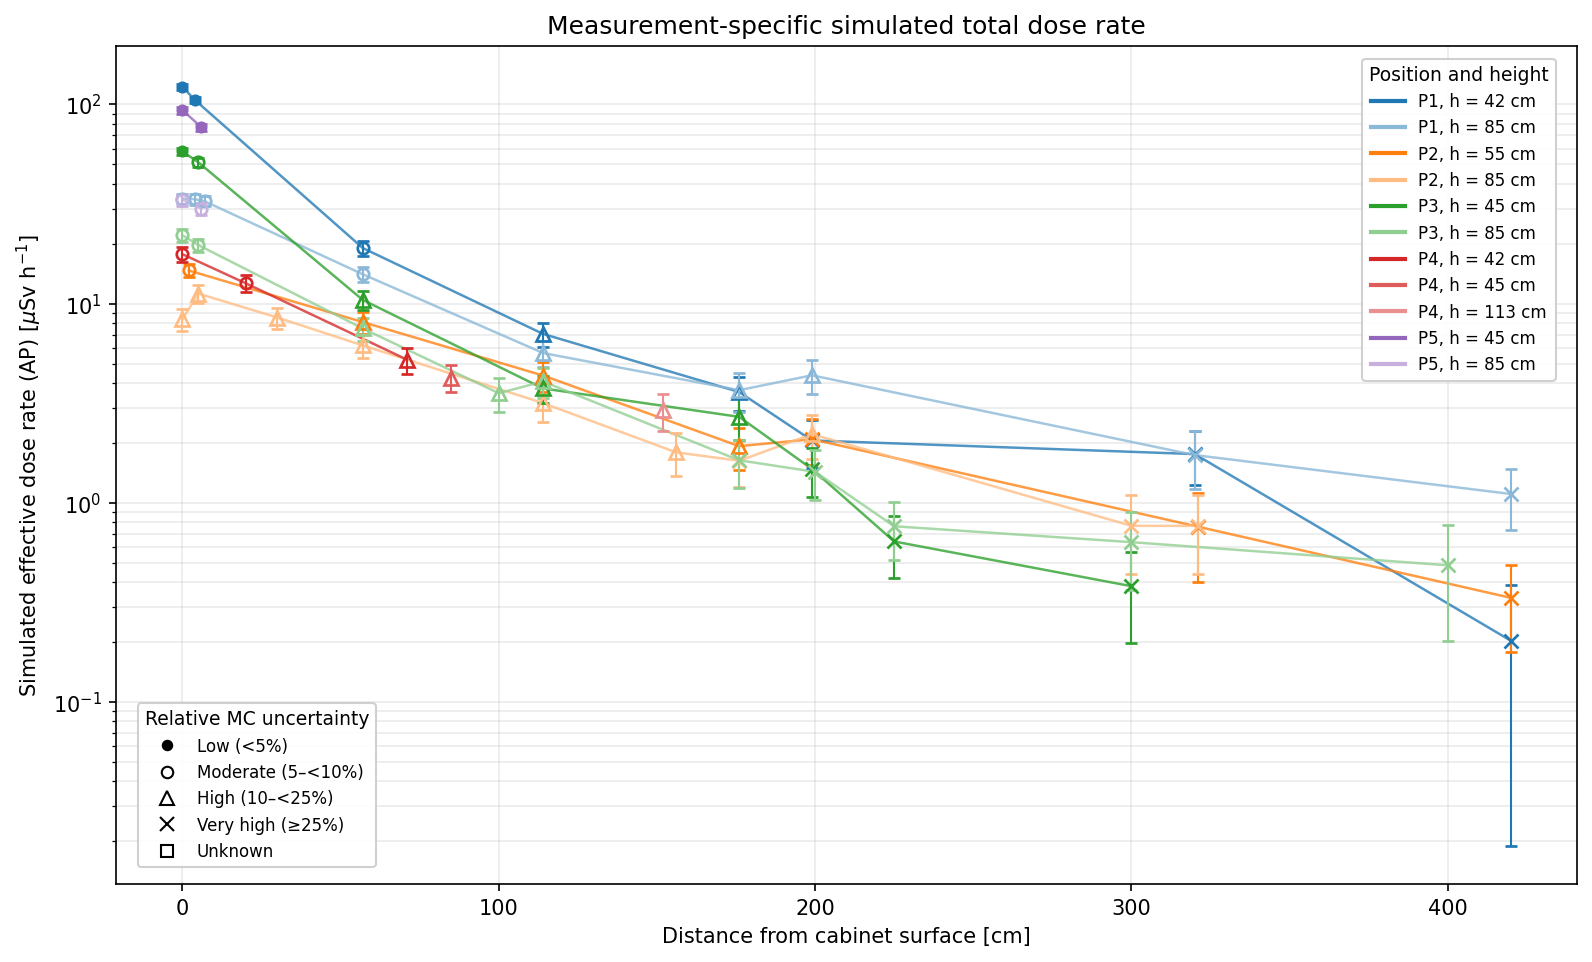

Saved figure: N3_simulated_unified_outputs/figures/measurement_specific_total_dose_rate_vs_distance.png


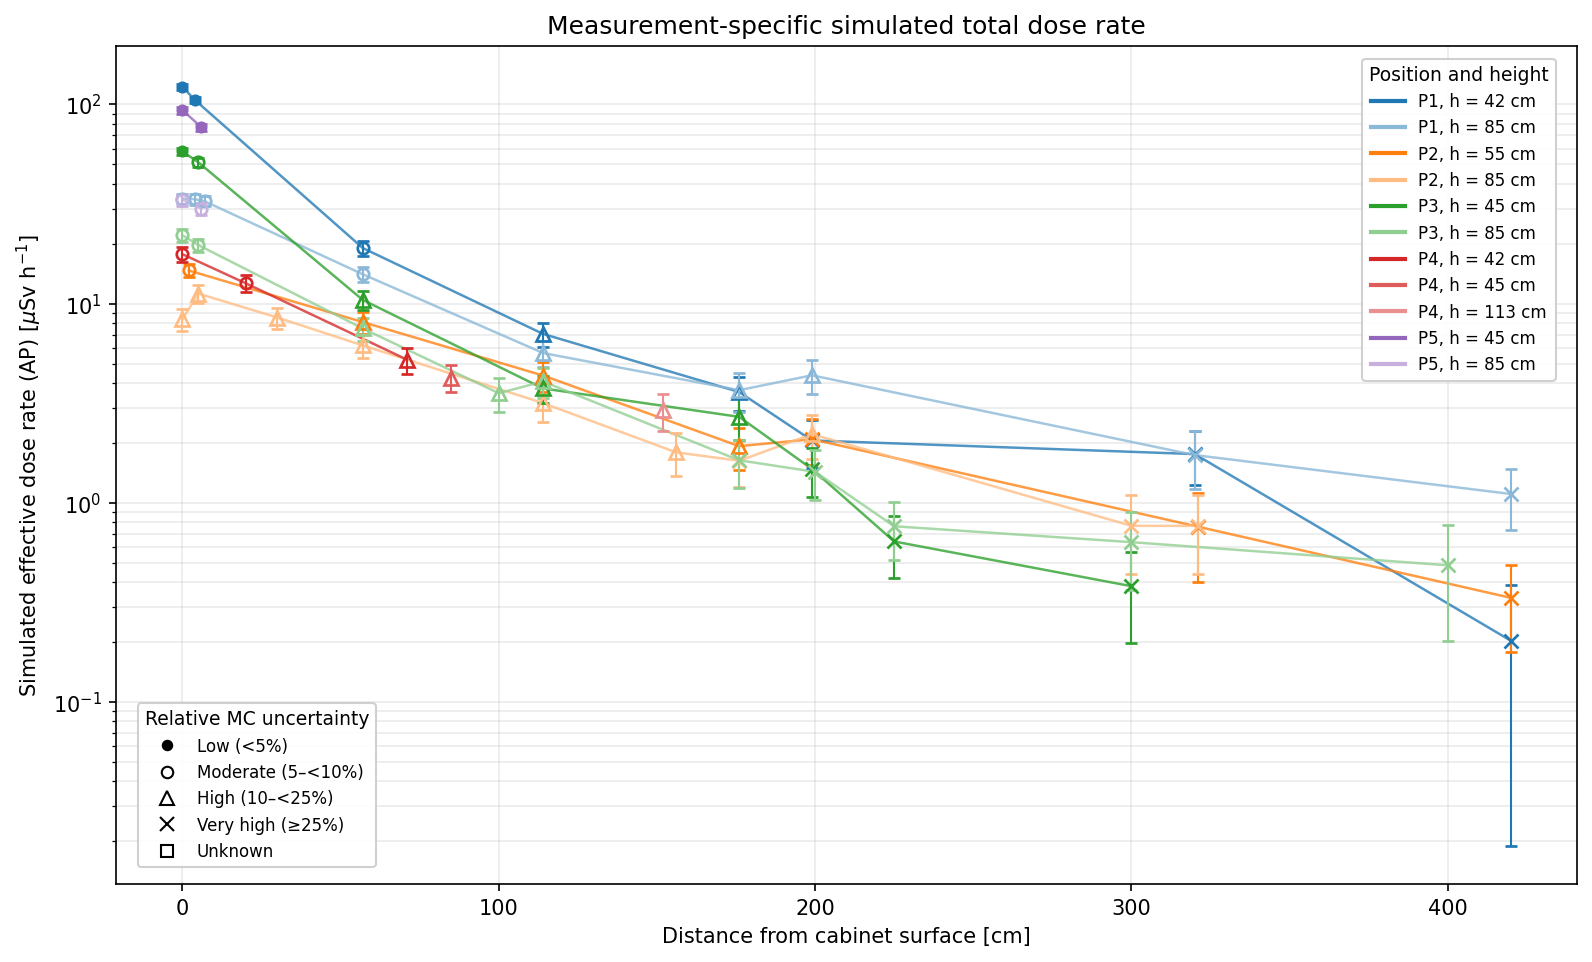

In [17]:
TOTAL_DOSE_COL = "total_dose_rate [uSv/h]"
TOTAL_DOSE_U_COL = "u_mc_total_dose_rate [uSv/h]"
TOTAL_DOSE_REL_U_COL = "rel_u_mc_total_dose_rate [%]"


def plot_total_dose_rate(
    dataframe,
    title,
    figure_path,
    figsize=(10.5, 6.3),
):
    """Plot total dose rate with the common P1--P5 visual convention."""

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=150,
        layout="constrained",
    )

    position_height_handles = []

    for (position, height_cm), curve_data in dataframe.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        curve_data = curve_data.sort_values("distance_cm")

        x = curve_data["distance_cm"].to_numpy(dtype=float)
        y = curve_data[TOTAL_DOSE_COL].to_numpy(dtype=float)
        yerr = curve_data[TOTAL_DOSE_U_COL].to_numpy(dtype=float)
        relative_uncertainty = curve_data[
            TOTAL_DOSE_REL_U_COL
        ].to_numpy(dtype=float)

        color = position_height_colors[
            (position, float(height_cm))
        ]

        line_y = np.where(
            np.isfinite(y) & (y > 0.0),
            y,
            np.nan,
        )

        ax.plot(
            x,
            line_y,
            color=color,
            linestyle="-",
            linewidth=1.2,
            alpha=0.78,
            label="_nolegend_",
            zorder=2,
        )

        add_uncertainty_errorbars(
            ax=ax,
            x=x,
            y=y,
            yerr=yerr,
            relative_uncertainty=relative_uncertainty,
            color=color,
        )

        position_height_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle="-",
                linewidth=2.0,
                label=f"{position}, h = {height_cm:g} cm",
            )
        )

    ax.set_yscale("log")
    ax.set_xlabel("Distance from cabinet surface [cm]")
    ax.set_ylabel(
        r"Simulated effective dose rate (AP) "
        r"[$\mu$Sv h$^{-1}$]"
    )
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)

    position_legend = ax.legend(
        handles=position_height_handles,
        title="Position and height",
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )
    ax.add_artist(position_legend)

    ax.legend(
        handles=make_uncertainty_legend_handles(),
        title="Relative MC uncertainty",
        loc="lower left",
        bbox_to_anchor=(0.015, 0.02),
        borderaxespad=0.0,
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(f"Saved figure: {figure_path}")
    return fig


total_dose_overview_path = (
    FIGURE_DIR / "measurement_specific_total_dose_rate_vs_distance.png"
)

plot_total_dose_rate(
    dataframe=unified_df,
    title="Measurement-specific simulated total dose rate",
    figure_path=total_dose_overview_path,
)


## 10.1) Lower- and upper-height comparisons

The same total-dose result is separated into the two measurement-height groups.
Exact heights remain visible through the colour shades and legend labels.


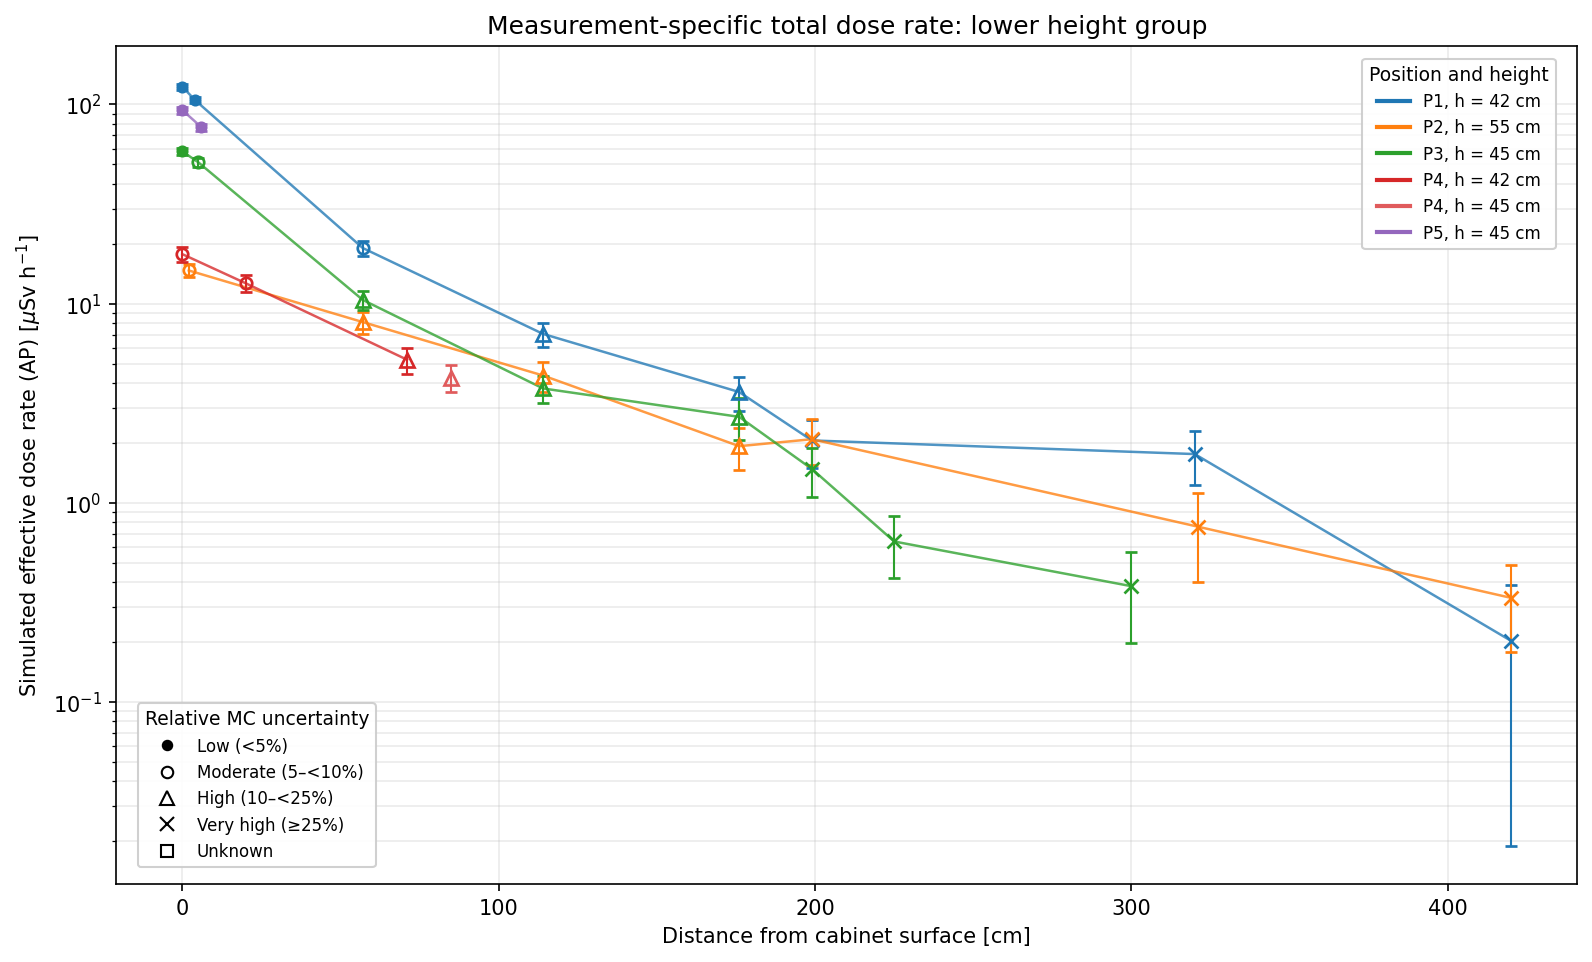

Saved figure: N3_simulated_unified_outputs/figures/total_dose_rate_lower_height_group.png


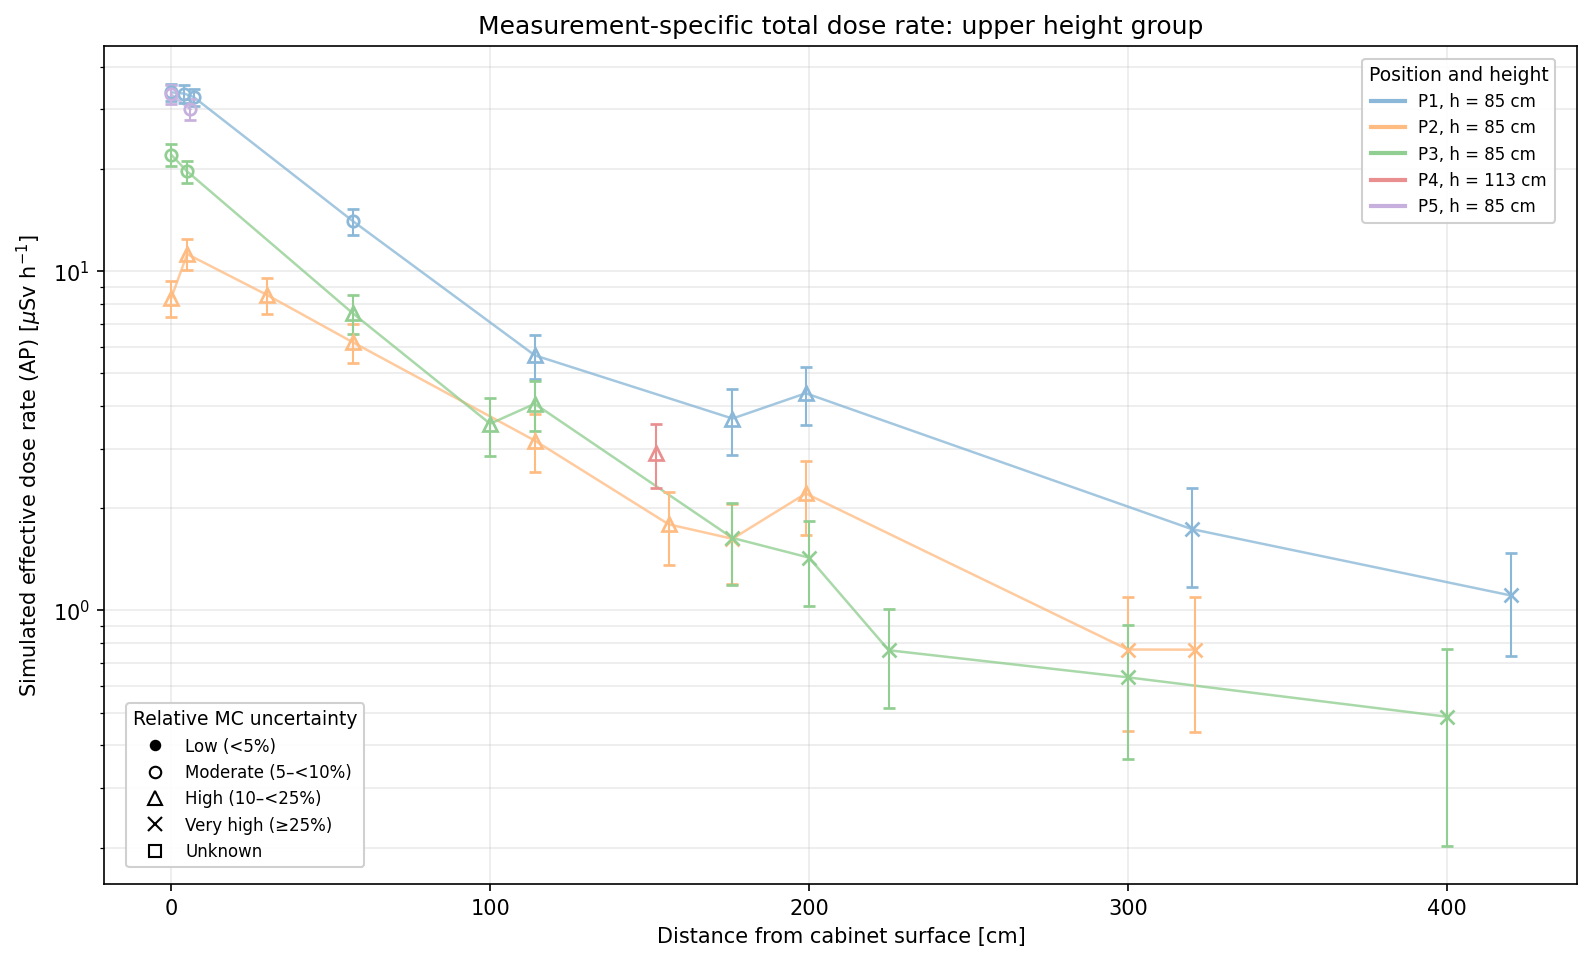

Saved figure: N3_simulated_unified_outputs/figures/total_dose_rate_upper_height_group.png


In [18]:
height_group_plot_settings = [
    (
        LOWER_HEIGHT_LABEL,
        "Measurement-specific total dose rate: lower height group",
        FIGURE_DIR / "total_dose_rate_lower_height_group.png",
    ),
    (
        UPPER_HEIGHT_LABEL,
        "Measurement-specific total dose rate: upper height group",
        FIGURE_DIR / "total_dose_rate_upper_height_group.png",
    ),
]

for height_group, title, figure_path in height_group_plot_settings:
    subset = unified_df.loc[
        unified_df["height_group"] == height_group
    ].copy()

    if subset.empty:
        print(f"No data found for {height_group}.")
        continue

    plot_total_dose_rate(
        dataframe=subset,
        title=title,
        figure_path=figure_path,
    )


# 11) Neutron, gamma, and total dose-rate components

Each panel represents one scan direction. Colour shade identifies the exact
height within that position; line style identifies the radiation component.
The shaded regions show the OpenMC $\pm1\sigma$ interval for each component.


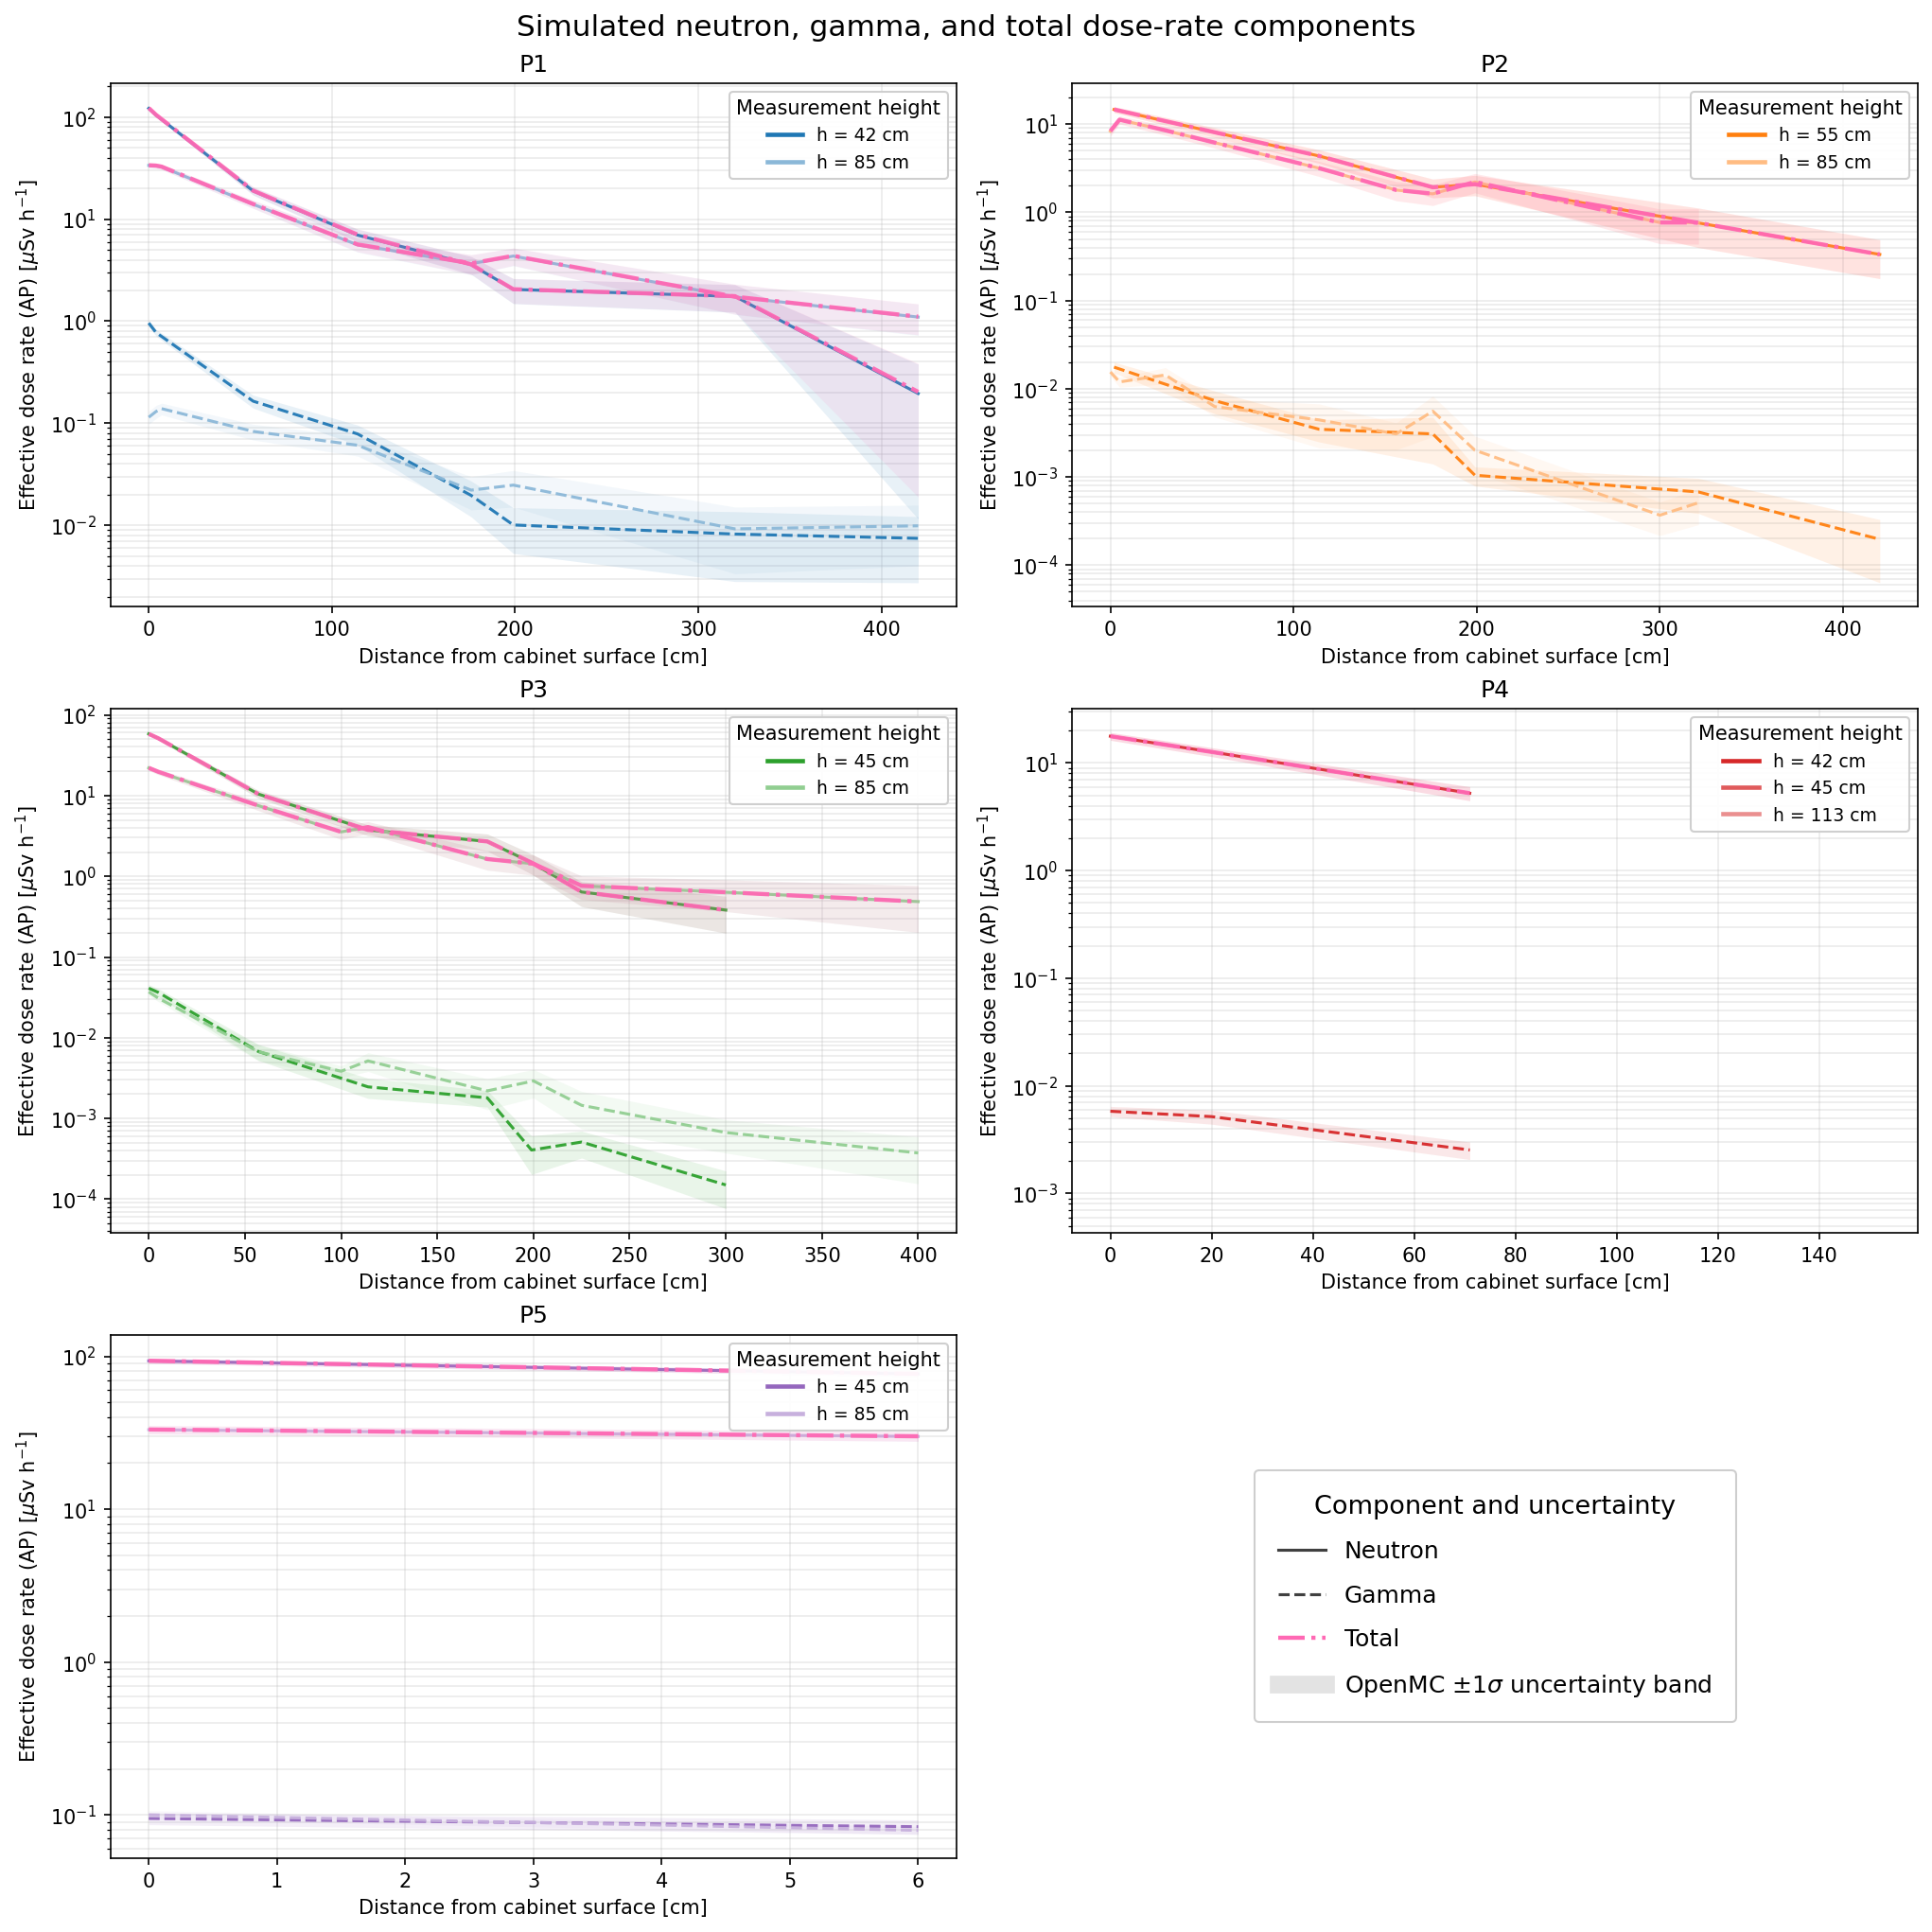

Saved figure: N3_simulated_unified_outputs/figures/dose_rate_components_by_position.png


In [22]:
component_settings = [
    {
        "label": "Neutron",
        "value_col": "neutron_dose_rate [uSv/h]",
        "u_col": "u_mc_neutron_dose_rate [uSv/h]",
        "linestyle": "-",
        "linewidth": 1.5,
        "fixed_color": None,
        "zorder": 3,
    },
    {
        "label": "Gamma",
        "value_col": "gamma_dose_rate [uSv/h]",
        "u_col": "u_mc_gamma_dose_rate [uSv/h]",
        "linestyle": "--",
        "linewidth": 1.5,
        "fixed_color": None,
        "zorder": 3,
    },
    {
        "label": "Total",
        "value_col": "total_dose_rate [uSv/h]",
        "u_col": "u_mc_total_dose_rate [uSv/h]",
        "linestyle": "-.",
        "linewidth": 2.1,
        "fixed_color": "hotpink",
        "zorder": 5,
    },
]

component_handles = [
    Line2D(
        [0],
        [0],
        color=(
            component["fixed_color"]
            if component["fixed_color"] is not None
            else "0.25"
        ),
        linestyle=component["linestyle"],
        linewidth=component["linewidth"],
        label=component["label"],
    )
    for component in component_settings
]

uncertainty_handle = Line2D(
    [0],
    [0],
    color="0.4",
    linestyle="-",
    linewidth=9,
    alpha=0.18,
    label=r"OpenMC $\pm1\sigma$ uncertainty band",
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(13.5, 13.5),
    dpi=150,
    layout="constrained",
)

axes = axes.flatten()

for axis_index, position in enumerate(POSITION_ORDER):
    ax = axes[axis_index]

    position_data = unified_df.loc[
        unified_df["position"] == position
    ].copy()

    if position_data.empty:
        ax.set_visible(False)
        continue

    height_handles = []

    for height_cm, curve_data in position_data.groupby(
        "height_cm",
        sort=True,
    ):
        curve_data = curve_data.sort_values("distance_cm")

        x = curve_data[
            "distance_cm"
        ].to_numpy(dtype=float)

        height_color = position_height_colors[
            (position, float(height_cm))
        ]

        for component in component_settings:
            y = curve_data[
                component["value_col"]
            ].to_numpy(dtype=float)

            yerr = curve_data[
                component["u_col"]
            ].to_numpy(dtype=float)

            curve_color = (
                component["fixed_color"]
                if component["fixed_color"] is not None
                else height_color
            )

            valid = (
                np.isfinite(x)
                & np.isfinite(y)
                & (y > 0.0)
            )

            ax.plot(
                x[valid],
                y[valid],
                color=curve_color,
                linestyle=component["linestyle"],
                linewidth=component["linewidth"],
                alpha=0.94,
                zorder=component["zorder"],
            )

            band_valid = (
                valid
                & np.isfinite(yerr)
                & (yerr >= 0.0)
            )

            if np.any(band_valid):
                lower = np.maximum(
                    y[band_valid] - yerr[band_valid],
                    np.finfo(float).tiny,
                )
                upper = (
                    y[band_valid]
                    + yerr[band_valid]
                )

                ax.fill_between(
                    x[band_valid],
                    lower,
                    upper,
                    color=curve_color,
                    alpha=0.10,
                    linewidth=0.0,
                    zorder=component["zorder"] - 1,
                )

        height_handles.append(
            Line2D(
                [0],
                [0],
                color=height_color,
                linestyle="-",
                linewidth=2.2,
                label=f"h = {height_cm:g} cm",
            )
        )

    ax.legend(
        handles=height_handles,
        title="Measurement height",
        loc="upper right",
        fontsize=9,
        title_fontsize=10,
        frameon=True,
        framealpha=0.94,
        facecolor="white",
    )

    ax.set_yscale("log")
    ax.set_title(position)
    ax.set_xlabel(
        "Distance from cabinet surface [cm]"
    )
    ax.set_ylabel(
        r"Effective dose rate (AP) "
        r"[$\mu$Sv h$^{-1}$]"
    )
    ax.grid(
        True,
        which="both",
        alpha=0.25,
    )

# Use the otherwise empty lower-right panel for the common legend.
legend_axis = axes[len(POSITION_ORDER)]
legend_axis.axis("off")
legend_axis.legend(
    handles=[
        *component_handles,
        uncertainty_handle,
    ],
    title="Component and uncertainty",
    loc="center",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    borderpad=1.0,
    labelspacing=0.9,
)

for unused_axis in axes[len(POSITION_ORDER) + 1:]:
    unused_axis.set_visible(False)

fig.suptitle(
    "Simulated neutron, gamma, and total dose-rate components",
    fontsize=15,
)

dose_component_figure_path = (
    FIGURE_DIR
    / "dose_rate_components_by_position.png"
)

fig.savefig(
    dose_component_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {dose_component_figure_path}")

# 12) Common-cube flux ratio, gamma dose fraction, and Monte Carlo precision

The local gamma-to-neutron flux ratio is shown only for the co-located common
cubes. The gamma dose fraction is shown separately; the neutron dose fraction
is its complement,

$$
f_n = 1-f_\gamma.
$$

A separate precision plot shows the relative MC uncertainty of the total dose
rate and the 5%, 10%, and 25% classification boundaries.


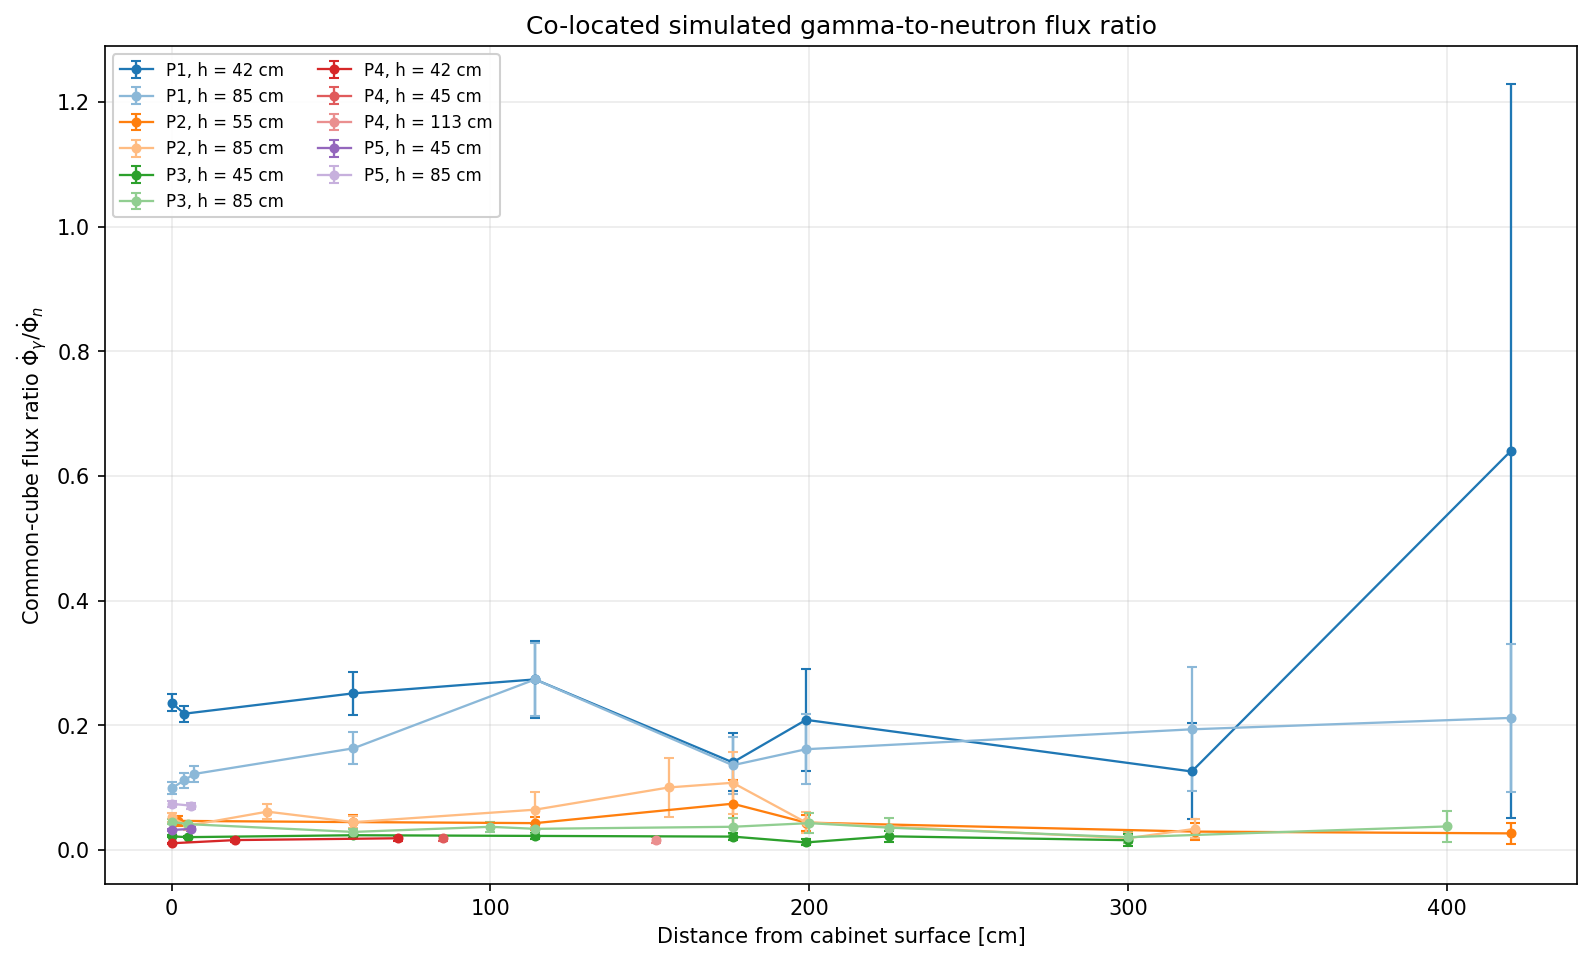

Saved figure: N3_simulated_unified_outputs/figures/common_gamma_to_neutron_flux_ratio.png


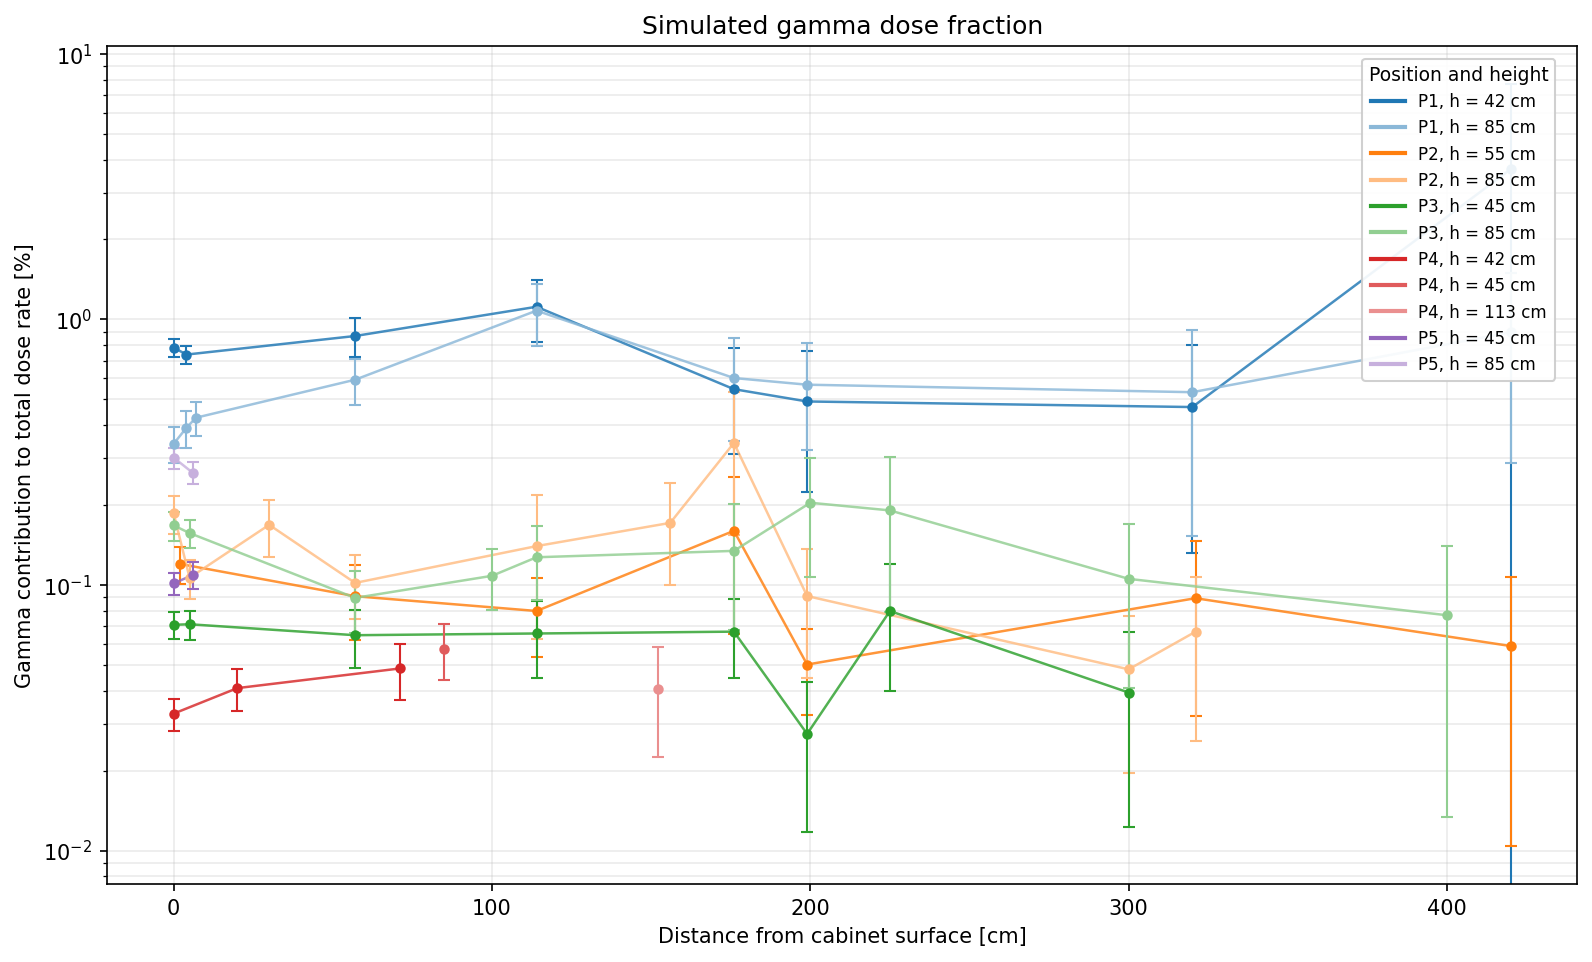

Saved figure: N3_simulated_unified_outputs/figures/gamma_dose_fraction_vs_distance.png


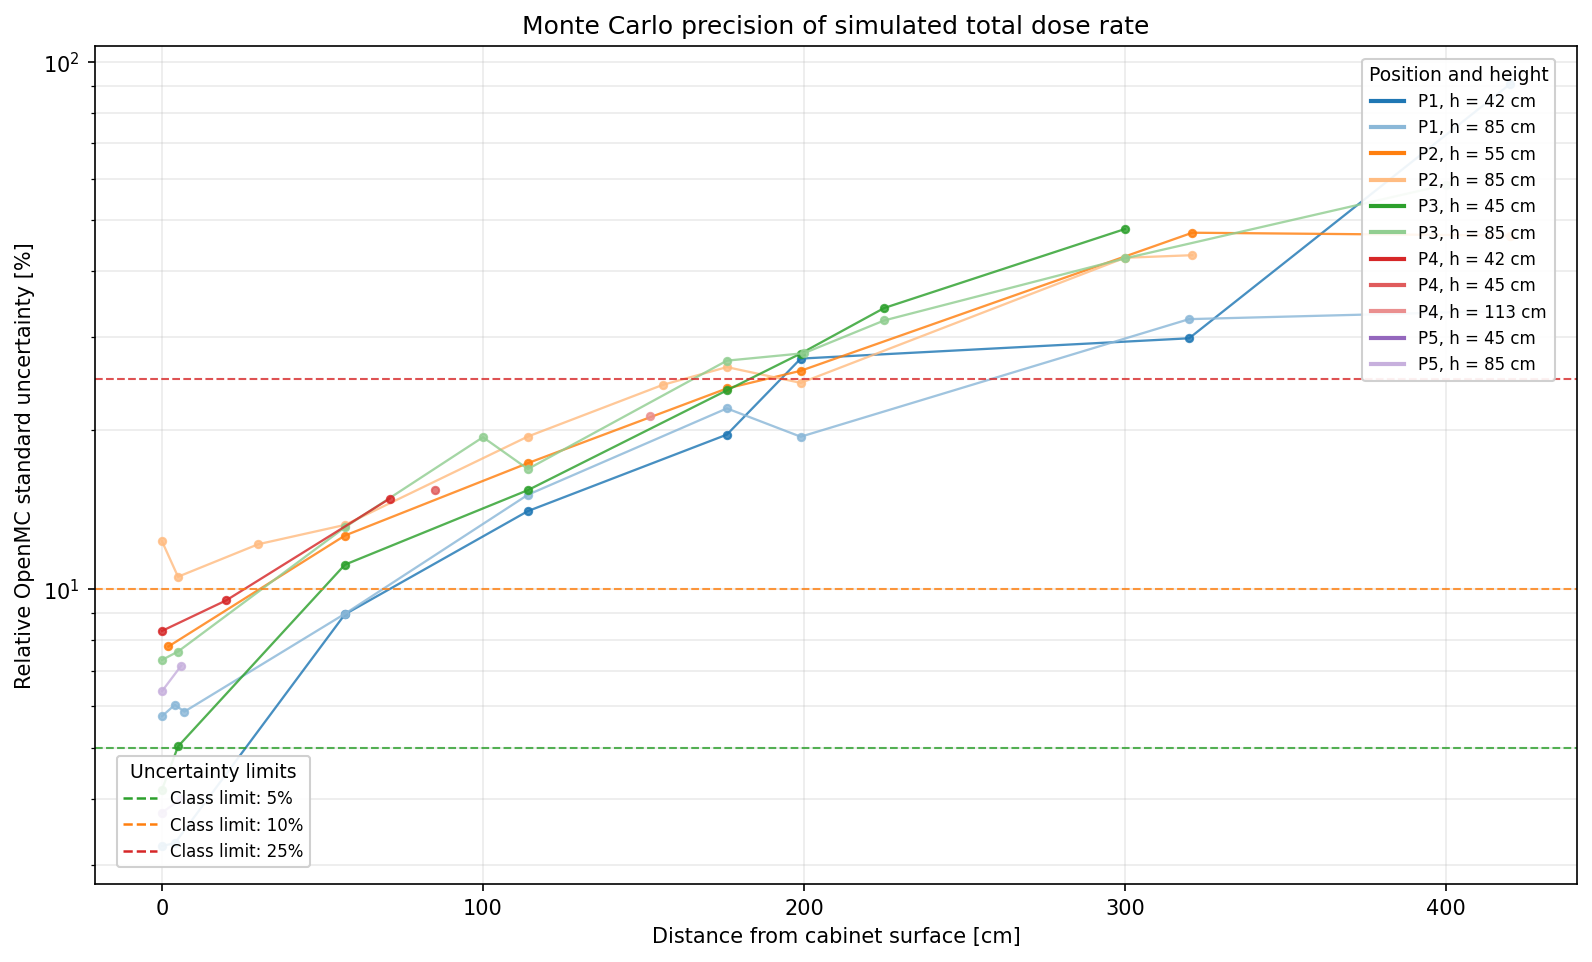

Saved figure: N3_simulated_unified_outputs/figures/total_dose_relative_mc_uncertainty.png


In [23]:
# ------------------------------------------------------------
# Co-located gamma-to-neutron flux ratio
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.3), dpi=150, layout="constrained")
for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"], sort=True
):
    curve_data = curve_data.sort_values("distance_cm")
    color = position_height_colors[(position, float(height_cm))]
    ax.errorbar(
        curve_data["distance_cm"],
        curve_data["common_gamma_to_neutron_flux_ratio"],
        yerr=curve_data["u_mc_common_gamma_to_neutron_flux_ratio"],
        marker="o",
        markersize=3.8,
        linewidth=1.1,
        capsize=2.5,
        color=color,
        label=f"{position}, h = {height_cm:g} cm",
    )
ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel(r"Common-cube flux ratio $\dot\Phi_\gamma/\dot\Phi_n$")
ax.set_title("Co-located simulated gamma-to-neutron flux ratio")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8, ncol=2, framealpha=0.92)
common_flux_ratio_figure_path = FIGURE_DIR / "common_gamma_to_neutron_flux_ratio.png"
fig.savefig(common_flux_ratio_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved figure: {common_flux_ratio_figure_path}")


# ------------------------------------------------------------
# Gamma dose fraction
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

fraction_handles = []

for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    curve_data = curve_data.sort_values("distance_cm")
    x = curve_data["distance_cm"].to_numpy(dtype=float)
    y = 100.0 * curve_data["gamma_dose_fraction"].to_numpy(dtype=float)
    yerr = (
        100.0
        * curve_data["u_mc_gamma_dose_fraction"].to_numpy(dtype=float)
    )
    color = position_height_colors[(position, float(height_cm))]

    valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)

    ax.plot(
        x[valid],
        y[valid],
        color=color,
        linewidth=1.2,
        alpha=0.82,
    )

    error_valid = valid & np.isfinite(yerr) & (yerr >= 0.0)

    ax.errorbar(
        x[error_valid],
        y[error_valid],
        yerr=yerr[error_valid],
        fmt="o",
        markersize=4.0,
        color=color,
        ecolor=color,
        capsize=3,
        linewidth=1.0,
    )

    fraction_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.0,
            label=f"{position}, h = {height_cm:g} cm",
        )
    )

positive_fraction = unified_df.loc[
    unified_df["gamma_dose_fraction"] > 0.0,
    "gamma_dose_fraction",
]

if not positive_fraction.empty:
    dynamic_range = (
        positive_fraction.max() / positive_fraction.min()
    )
    if dynamic_range >= 100.0:
        ax.set_yscale("log")

ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel("Gamma contribution to total dose rate [%]")
ax.set_title("Simulated gamma dose fraction")
ax.grid(True, which="both", alpha=0.25)
ax.legend(
    handles=fraction_handles,
    title="Position and height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)

gamma_fraction_figure_path = (
    FIGURE_DIR / "gamma_dose_fraction_vs_distance.png"
)

fig.savefig(
    gamma_fraction_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {gamma_fraction_figure_path}")


# ------------------------------------------------------------
# Relative MC uncertainty of total dose rate
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

uncertainty_curve_handles = []

for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    curve_data = curve_data.sort_values("distance_cm")
    color = position_height_colors[(position, float(height_cm))]

    ax.plot(
        curve_data["distance_cm"],
        curve_data["rel_u_mc_total_dose_rate [%]"],
        marker="o",
        markersize=3.5,
        linewidth=1.1,
        alpha=0.82,
        color=color,
    )

    uncertainty_curve_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.0,
            label=f"{position}, h = {height_cm:g} cm",
        )
    )

threshold_settings = [
    (MC_LOW_U_MAX_PERCENT, "5%", "tab:green"),
    (MC_MODERATE_U_MAX_PERCENT, "10%", "tab:orange"),
    (MC_HIGH_U_MAX_PERCENT, "25%", "tab:red"),
]

threshold_handles = []

for threshold, label, color in threshold_settings:
    ax.axhline(
        threshold,
        color=color,
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
    )
    threshold_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linestyle="--",
            linewidth=1.2,
            label=f"Class limit: {label}",
        )
    )

positive_uncertainties = unified_df.loc[
    unified_df["rel_u_mc_total_dose_rate [%]"] > 0.0,
    "rel_u_mc_total_dose_rate [%]",
]

if not positive_uncertainties.empty:
    ax.set_yscale("log")

ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel("Relative OpenMC standard uncertainty [%]")
ax.set_title("Monte Carlo precision of simulated total dose rate")
ax.grid(True, which="both", alpha=0.25)

curve_legend = ax.legend(
    handles=uncertainty_curve_handles,
    title="Position and height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)
ax.add_artist(curve_legend)

ax.legend(
    handles=threshold_handles,
    title="Uncertainty limits",
    loc="lower left",
    bbox_to_anchor=(0.015, 0.02),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)

total_uncertainty_figure_path = (
    FIGURE_DIR / "total_dose_relative_mc_uncertainty.png"
)

fig.savefig(
    total_uncertainty_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {total_uncertainty_figure_path}")


# 13) Spatial view of the unified dose-tally positions

Several heights share the same $(x,y)$ coordinate. The spatial colour map
therefore uses the median total dose rate across the available heights at each
plan-view point. The full height-resolved results remain in the final table and
distance plots. The map uses `common_dose_x_cm` and `common_dose_y_cm`; it does
not use the displaced LND 712 gamma-flux centres.


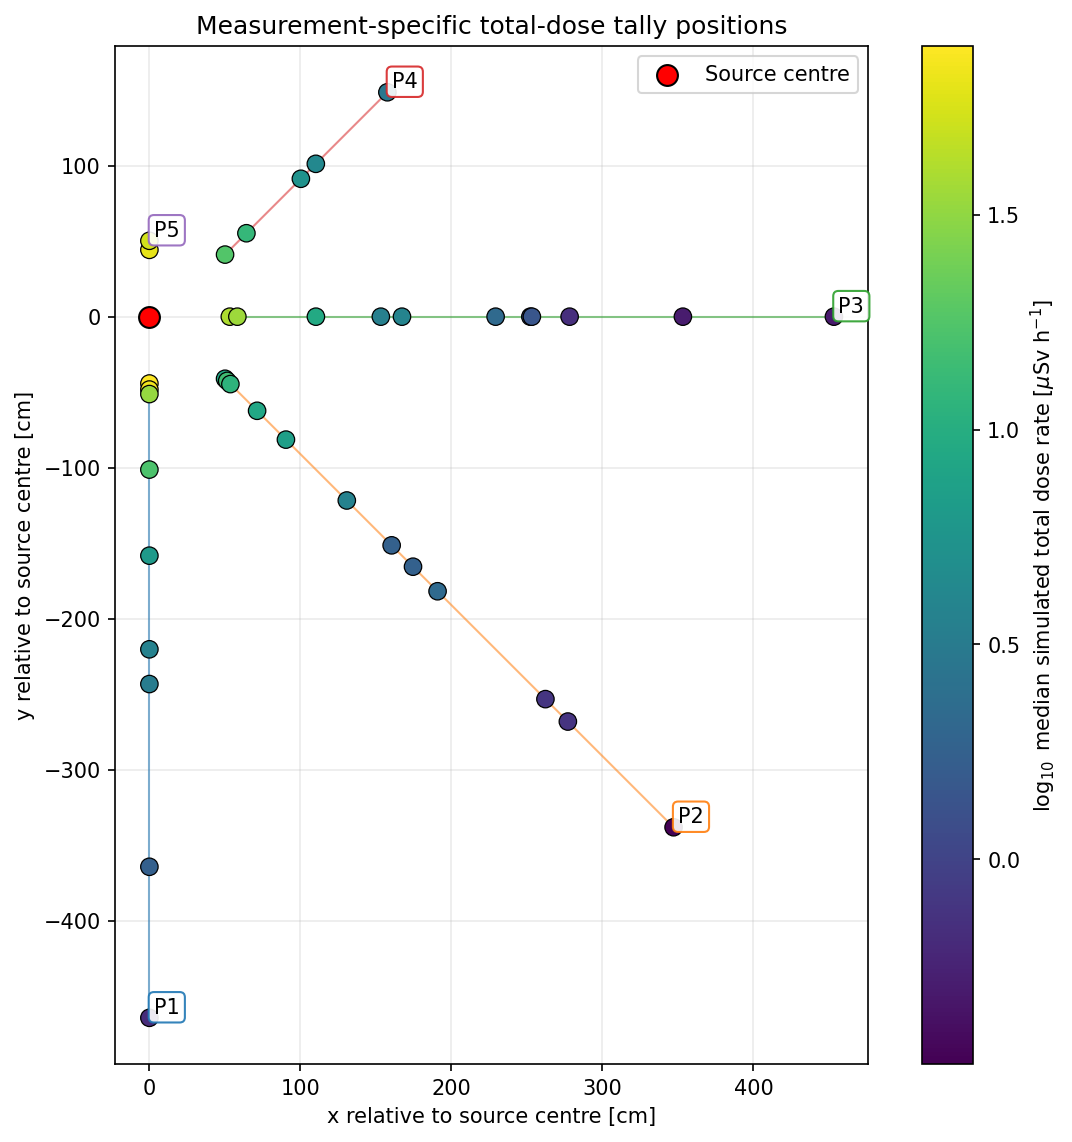

Saved figure: N3_simulated_unified_outputs/figures/measurement_specific_total_dose_xy_map.png


In [24]:
spatial_total_dose_df = (
    unified_df
    .groupby(
        [
            "position",
            "distance_cm",
            "common_dose_x_cm",
            "common_dose_y_cm",
        ],
        as_index=False,
    )
    .agg(
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        number_of_heights=("height_cm", "nunique"),
    )
)

positive_spatial_data = spatial_total_dose_df.loc[
    spatial_total_dose_df["median_total_dose_rate_uSv_h"] > 0.0
].copy()

if positive_spatial_data.empty:
    raise ValueError("No positive total dose rates are available for the map.")

fig, ax = plt.subplots(
    figsize=(8.5, 7.5),
    dpi=150,
    layout="constrained",
)

scatter = ax.scatter(
    positive_spatial_data["common_dose_x_cm"],
    positive_spatial_data["common_dose_y_cm"],
    c=np.log10(
        positive_spatial_data["median_total_dose_rate_uSv_h"]
    ),
    s=70,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
)

for position, position_data in positive_spatial_data.groupby(
    "position",
    sort=True,
):
    xy_data = position_data.sort_values("distance_cm")

    ax.plot(
        xy_data["common_dose_x_cm"],
        xy_data["common_dose_y_cm"],
        color=POSITION_COLORS[position],
        linewidth=1.0,
        alpha=0.55,
        zorder=2,
    )

    label_row = xy_data.iloc[-1]

    ax.text(
        label_row["common_dose_x_cm"] + 3.0,
        label_row["common_dose_y_cm"] + 3.0,
        position,
        fontsize=10,
        fontweight="normal",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": POSITION_COLORS[position],
            "alpha": 0.90,
        },
        zorder=6,
    )

ax.scatter(
    [0.0],
    [0.0],
    s=100,
    color="red",
    edgecolor="black",
    label="Source centre",
    zorder=5,
)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(
    r"$\log_{10}$ median simulated total dose rate "
    r"[$\mu$Sv h$^{-1}$]"
)

ax.set_xlabel("x relative to source centre [cm]")
ax.set_ylabel("y relative to source centre [cm]")
ax.set_title("Measurement-specific total-dose tally positions")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="best", frameon=True)

spatial_map_figure_path = (
    FIGURE_DIR / "measurement_specific_total_dose_xy_map.png"
)

fig.savefig(
    spatial_map_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {spatial_map_figure_path}")


# 14) Save final tables, metadata, and figure inventory

The principal downstream product is
`unified_simulated_radiation_field_final.csv`. It contains the separate fluxes,
all three coordinate definitions, component dose rates, total dose rate, dose
fractions, dose ratios, and MC-only standard uncertainties for all 61 scan
points. It also contains the co-located common-cube neutron and gamma fluxes,
their local ratio, and their arithmetic total particle flux.


In [25]:
unified_output_csv = (
    TABLE_DIR / "unified_simulated_radiation_field_final.csv"
)
main_unified_output_csv = Path(
    "unified_simulated_radiation_field_final.csv"
)

neutron_dose_output_csv = (
    TABLE_DIR / "measurement_specific_neutron_dose_rate.csv"
)
gamma_dose_output_csv = (
    TABLE_DIR / "measurement_specific_gamma_dose_rate.csv"
)
common_neutron_flux_output_csv = (
    TABLE_DIR / "common_cube_neutron_flux.csv"
)
common_gamma_flux_output_csv = (
    TABLE_DIR / "common_cube_gamma_flux.csv"
)
position_summary_csv = (
    TABLE_DIR / "simulated_radiation_field_position_summary.csv"
)
height_position_summary_csv = (
    TABLE_DIR / "simulated_radiation_field_height_position_summary.csv"
)
uncertainty_counts_csv = (
    TABLE_DIR / "total_dose_mc_uncertainty_class_counts.csv"
)
very_high_uncertainty_csv = (
    TABLE_DIR / "total_dose_very_high_mc_uncertainty_points.csv"
)
spatial_plotting_data_csv = (
    TABLE_DIR / "total_dose_spatial_plotting_data.csv"
)
coordinate_definition_csv = (
    TABLE_DIR / "notebook_3_tally_coordinate_definitions.csv"
)
gamma_dose_trigger_audit_csv = (
    TABLE_DIR / "gamma_dose_trigger_audit.csv"
)


unified_df.to_csv(unified_output_csv, index=False)
unified_df.to_csv(main_unified_output_csv, index=False)
neutron_dose_df.to_csv(neutron_dose_output_csv, index=False)
gamma_dose_df.to_csv(gamma_dose_output_csv, index=False)
common_neutron_flux_df.to_csv(common_neutron_flux_output_csv, index=False)
common_gamma_flux_df.to_csv(common_gamma_flux_output_csv, index=False)
position_summary_df.to_csv(position_summary_csv, index=False)
height_position_summary_df.to_csv(
    height_position_summary_csv,
    index=False,
)
total_dose_uncertainty_counts_df.to_csv(
    uncertainty_counts_csv,
    index=False,
)
very_high_total_dose_uncertainty_points_df.to_csv(
    very_high_uncertainty_csv,
    index=False,
)
spatial_total_dose_df.to_csv(spatial_plotting_data_csv, index=False)

coordinate_definition_df = unified_df[
    [
        "position",
        "point_name",
        "distance_cm",
        "height_cm",
        "neutron_flux_x_cm",
        "neutron_flux_y_cm",
        "neutron_flux_z_cm",
        "gamma_flux_x_cm",
        "gamma_flux_y_cm",
        "gamma_flux_z_cm",
        "common_dose_x_cm",
        "common_dose_y_cm",
        "common_dose_z_cm",
        "common_flux_x_cm",
        "common_flux_y_cm",
        "common_flux_z_cm",
        "common_flux_tally_volume_cm3",
        "flux_centre_separation_cm",
    ]
].copy()
coordinate_definition_df.to_csv(coordinate_definition_csv, index=False)
GAMMA_DOSE_TRIGGER_AUDIT_DF.to_csv(
    gamma_dose_trigger_audit_csv,
    index=False,
)


metadata_rows = [
    {
        "quantity": "notebook",
        "value": "Notebook_3.ipynb",
        "unit": "",
    },
    {
        "quantity": "number_of_scan_points",
        "value": len(unified_df),
        "unit": "points",
    },
    {
        "quantity": "source_manufacturer",
        "value": SOURCE_MANUFACTURER,
        "unit": "",
    },
    {
        "quantity": "source_model",
        "value": SOURCE_MODEL,
        "unit": "",
    },
    {
        "quantity": "source_serial_number",
        "value": SOURCE_SERIAL_NUMBER,
        "unit": "",
    },
    {
        "quantity": "factory_neutron_emission_reference",
        "value": SOURCE_NEUTRON_EMISSION_REF,
        "unit": "n/s",
    },
    {
        "quantity": "factory_neutron_emission_reference_date",
        "value": SOURCE_NEUTRON_EMISSION_REF_DATE,
        "unit": "",
    },
    {
        "quantity": "selected_neutron_emission",
        "value": SOURCE_NEUTRON_EMISSION,
        "unit": "n/s",
    },
    {
        "quantity": "selected_neutron_emission_date",
        "value": SOURCE_EVALUATION_DATE,
        "unit": "",
    },
    {
        "quantity": "neutron_source_normalization_status",
        "value": SOURCE_NORMALIZATION_STATUS,
        "unit": "",
    },
    {
        "quantity": "alphanso_neutron_yield_key",
        "value": alphanso_neutron_yield_key,
        "unit": "",
    },
    {
        "quantity": "alphanso_neutron_yield",
        "value": alphanso_neutron_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": "alphanso_gamma_yield",
        "value": alphanso_gamma_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": "alphanso_gamma_to_neutron_ratio",
        "value": GAMMA_TO_NEUTRON_RATIO_ALPHANSO,
        "unit": "photons/neutron",
    },
    {
        "quantity": "selected_gamma_emission",
        "value": GAMMA_SOURCE_EMISSION,
        "unit": "photons/s",
    },
    {
        "quantity": "gamma_source_normalization_status",
        "value": GAMMA_SOURCE_NORMALIZATION_STATUS,
        "unit": "",
    },
    {
        "quantity": "dose_coefficient_data_source",
        "value": DOSE_DATA_SOURCE,
        "unit": "",
    },
    {
        "quantity": "dose_quantity",
        "value": DOSE_QUANTITY,
        "unit": "",
    },
    {
        "quantity": "dose_irradiation_geometry",
        "value": DOSE_GEOMETRY,
        "unit": "",
    },
    {
        "quantity": "dose_detector_side_length",
        "value": DOSE_SCAN_DET_SIZE,
        "unit": "cm",
    },
    {
        "quantity": "dose_detector_volume",
        "value": DOSE_SCAN_DET_VOLUME,
        "unit": "cm3",
    },
    {
        "quantity": "neutron_flux_tally_definition",
        "value": (
            "Notebook 2 virtual flux tally at neutron_flux_x/y/z coordinates"
        ),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_tally_definition",
        "value": (
            "LND 712 finite active CSG cylinder with CellFilter at "
            "gamma_flux_x/y/z coordinates"
        ),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_lnd712_active_volume",
        "value": GAMMA_FLUX_LND712_VOLUME_CM3,
        "unit": "cm3",
    },
    {
        "quantity": "notebook_2_5_group_1_configured_relative_error_target",
        "value": GROUP_1_FLUX_TARGET_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "notebook_2_5_group_1_target_reached",
        "value": GROUP_1_FLUX_TARGET_REACHED,
        "unit": "boolean",
    },
    {
        "quantity": "notebook_2_5_group_1_maximum_relative_error",
        "value": GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "notebook_2_5_gamma_input_convergence_status",
        "value": N2_5_GAMMA_INPUT_CONVERGENCE_STATUS,
        "unit": "",
    },
    {
        "quantity": "gamma_flux_reference_offset_to_active_centre",
        "value": GAMMA_FLUX_REFERENCE_OFFSET_CM,
        "unit": "cm",
    },
    {
        "quantity": "common_dose_tally_definition",
        "value": (
            "2 x 2 x 2 cm virtual cube at common_dose_x/y/z coordinates; "
            "coordinates equal Notebook 2 neutron-flux centres"
        ),
        "unit": "",
    },
    {
        "quantity": "common_flux_tally_definition",
        "value": (
            "unweighted neutron and photon flux tallies in identical "
            "2 x 2 x 2 cm virtual cubes at the Notebook 2 Studsvik-reference "
            "centres"
        ),
        "unit": "",
    },
    {
        "quantity": "common_flux_tally_volume",
        "value": DOSE_SCAN_DET_VOLUME,
        "unit": "cm3",
    },
    {
        "quantity": "height_group_boundary",
        "value": HEIGHT_GROUP_BOUNDARY_CM,
        "unit": "cm",
    },
    {
        "quantity": "height_group_method",
        "value": "midpoint of largest gap between unique loaded heights",
        "unit": "",
    },
    {
        "quantity": "legacy_xyz_coordinate_alias",
        "value": "x_cm/y_cm/z_cm equal common_dose_x/y/z_cm",
        "unit": "",
    },
    {
        "quantity": "gamma_to_neutron_flux_ratio_status",
        "value": (
            "calculated only from co-located 2 x 2 x 2 cm common-cube tallies; "
            "detector-specific Notebook 2/2.5 fluxes are not ratioed"
        ),
        "unit": "",
    },
    {
        "quantity": "neutron_dose_batches",
        "value": NEUTRON_DOSE_RUN_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "neutron_dose_particles_per_batch",
        "value": NEUTRON_DOSE_RUN_PARTICLES,
        "unit": "source neutrons/batch",
    },
    {
        "quantity": "neutron_dose_total_histories",
        "value": NEUTRON_DOSE_RUN_BATCHES * NEUTRON_DOSE_RUN_PARTICLES,
        "unit": "source neutrons",
    },
    {
        "quantity": "gamma_dose_variance_reduction_method",
        "value": "Notebook 2.5 MAGIC photon weight windows",
        "unit": "",
    },
    {
        "quantity": "gamma_dose_weight_window_file",
        "value": str(GROUP_1_WEIGHT_WINDOWS_PATH),
        "unit": "",
    },
    {
        "quantity": "gamma_dose_relative_error_target",
        "value": 100.0 * GAMMA_DOSE_TARGET_REL_ERR,
        "unit": "%",
    },
    {
        "quantity": "gamma_dose_minimum_batches",
        "value": GAMMA_DOSE_MIN_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_maximum_batches",
        "value": GAMMA_DOSE_MAX_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_trigger_batch_interval",
        "value": GAMMA_DOSE_TRIGGER_BATCH_INTERVAL,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_completed_batches",
        "value": GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_particles_per_batch",
        "value": GAMMA_DOSE_PARTICLES_PER_BATCH,
        "unit": "source photons/batch",
    },
    {
        "quantity": "gamma_dose_total_histories",
        "value": (
            GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED
            * GAMMA_DOSE_PARTICLES_PER_BATCH
        ),
        "unit": "source photons",
    },
    {
        "quantity": "gamma_dose_maximum_relative_error",
        "value": GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "gamma_dose_target_reached",
        "value": GAMMA_DOSE_TARGET_REACHED,
        "unit": "",
    },
    {
        "quantity": "neutron_dose_statepoint",
        "value": str(sp_path_neutron_dose),
        "unit": "",
    },
    {
        "quantity": "gamma_dose_statepoint",
        "value": str(sp_path_gamma_dose),
        "unit": "",
    },
    {
        "quantity": "reported_uncertainty_scope",
        "value": "OpenMC batch-statistical standard uncertainty only",
        "unit": "",
    },
    {
        "quantity": "excluded_uncertainty_sources",
        "value": (
            "source certificate, decay correction, ALPHANSO yields and "
            "spectra, geometry, materials, nuclear data, detector response"
        ),
        "unit": "",
    },
    {
        "quantity": "neutron_flux_input",
        "value": str(neutron_flux_path),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_input",
        "value": str(gamma_flux_path),
        "unit": "",
    },
    {
        "quantity": "unified_output",
        "value": str(unified_output_csv),
        "unit": "",
    },
]

metadata_df = pd.DataFrame(metadata_rows)
metadata_path = METADATA_DIR / "notebook_3_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)


saved_figure_paths = sorted(FIGURE_DIR.glob("*.png"))

print("Saved final Notebook 3 outputs:")
print(f"  Unified table: {unified_output_csv}")
print(f"  Main copy:     {main_unified_output_csv}")
print(f"  Metadata:      {metadata_path}")
print(f"  Coordinates:   {coordinate_definition_csv}")
print(f"  Gamma audit:   {gamma_dose_trigger_audit_csv}")
print(f"  Figures:       {len(saved_figure_paths)}")

for figure_path in saved_figure_paths:
    print(f"    {figure_path}")


Saved final Notebook 3 outputs:
  Unified table: N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv
  Main copy:     unified_simulated_radiation_field_final.csv
  Metadata:      N3_simulated_unified_outputs/metadata/notebook_3_metadata.csv
  Coordinates:   N3_simulated_unified_outputs/tables/notebook_3_tally_coordinate_definitions.csv
  Gamma audit:   N3_simulated_unified_outputs/tables/gamma_dose_trigger_audit.csv
  Figures:       9
    N3_simulated_unified_outputs/figures/common_gamma_to_neutron_flux_ratio.png
    N3_simulated_unified_outputs/figures/dose_rate_components_by_position.png
    N3_simulated_unified_outputs/figures/gamma_dose_fraction_vs_distance.png
    N3_simulated_unified_outputs/figures/measurement_specific_total_dose_rate_vs_distance.png
    N3_simulated_unified_outputs/figures/measurement_specific_total_dose_xy_map.png
    N3_simulated_unified_outputs/figures/section_4_dose_conversion_coefficients.png
    N3_simulated_unified_outputs/fig

# 15) Simulated instrument-equivalent comparison field

Notebook 6 requires a simulated quantity corresponding to Notebook 5's measured
instrument-indicated field. The two components retain their detector-specific
reference geometries and are paired only by the identical nominal scan key.

Because complete numerical response matrices are unavailable, these values are
explicit proxies:

$$
\dot H_{\mathrm{n,2202D-eq,sim}}
\equiv \dot E_{\mathrm{AP,n}}
$$

at the Studsvik reference centre, and

$$
\dot H_{\mathrm{\gamma,GCA-Cs137-eq,sim}}
=
\dot\Phi_{\gamma,\mathrm{LND712}}
\,h_{\gamma,\mathrm{AP}}(661.657\ \mathrm{keV}).
$$

The second expression is a Cs-137-reference fluence-to-dose proxy, not a full
GM-tube pulse-response calculation. The combined value is used only for a
like-labelled comparison with Notebook 5 and must not be called AP effective
dose.

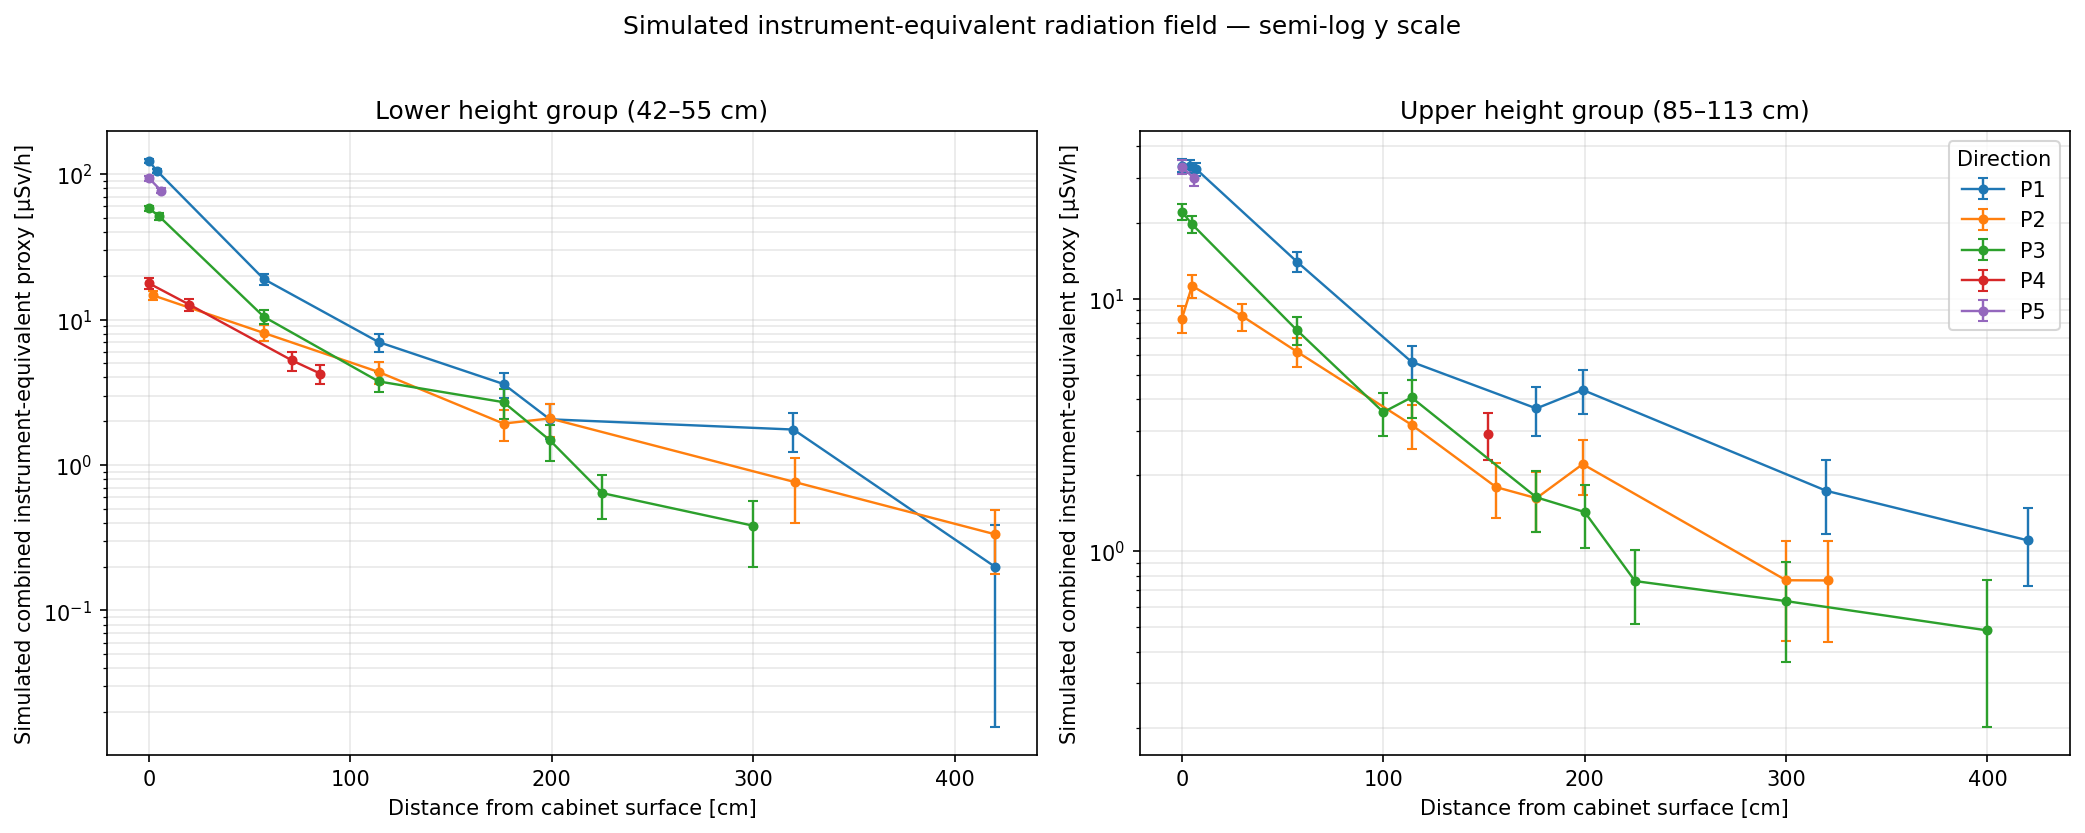

In [28]:
# ------------------------------------------------------------
# Component and combined overview — semi-log y scale
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.4),
    dpi=150,
    sharey=False,
)

for axis, group_label in zip(
    axes,
    [LOWER_HEIGHT_LABEL, UPPER_HEIGHT_LABEL],
):
    group = instrument_proxy_df.loc[
        instrument_proxy_df["height_group"].eq(group_label)
    ]

    for position in POSITION_ORDER:
        curve = (
            group.loc[group["position"].eq(position)]
            .sort_values("distance_cm")
        )

        if curve.empty:
            continue

        x = curve["distance_cm"].to_numpy(dtype=float)
        y = curve[
            "simulated_combined_instrument_indication [uSv/h]"
        ].to_numpy(dtype=float)
        yerr = curve[
            "u_mc_simulated_combined_instrument_indication [uSv/h]"
        ].to_numpy(dtype=float)

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
            & np.isfinite(yerr)
            & (y > 0.0)
            & (yerr >= 0.0)
        )

        if not np.any(valid):
            continue

        x = x[valid]
        y = y[valid]
        yerr = yerr[valid]

        # Keep the lower uncertainty limit positive on the log scale.
        log_yerr = np.vstack(
            [
                np.minimum(yerr, y * (1.0 - 1.0e-6)),
                yerr,
            ]
        )

        axis.errorbar(
            x,
            y,
            yerr=log_yerr,
            marker="o",
            markersize=3.8,
            linewidth=1.15,
            capsize=2.5,
            color=POSITION_COLORS[position],
            label=position,
        )

    axis.set_yscale("log")
    axis.set_title(group_label)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(
        "Simulated combined instrument-equivalent proxy [µSv/h]"
    )
    axis.grid(True, which="both", alpha=0.28)

axes[1].legend(
    title="Direction",
    loc="best",
)

fig.suptitle(
    "Simulated instrument-equivalent radiation field — semi-log y scale",
    y=1.02,
)
fig.tight_layout()

instrument_proxy_figure_path = (
    FIGURE_DIR / "simulated_instrument_equivalent_field.png"
)

fig.savefig(
    instrument_proxy_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# 16) Summary, interpretation, and limitations

Notebook 3 produces a unified theoretical radiation-field dataset at the 61
measurement-specific P1--P5 configurations. It preserves the detector-specific
Notebook 2 neutron flux and Notebook 2.5 LND 712 gamma flux with their original
coordinates, volumes, and pointwise Monte Carlo uncertainties. These two
detector-specific fluxes are not divided to form a ratio because they are not
co-located or averaged over the same geometry.

Separate neutron and photon transport calculations score AP-effective-dose and
unweighted flux in identical $2\times2\times2\ \mathrm{cm^3}$ reference cubes.
Only these co-located physical quantities are combined:

$$
\dot E_{\mathrm{AP,tot}}
=
\dot E_{\mathrm{AP,n}}
+
\dot E_{\mathrm{AP,\gamma}},
$$

and the local $\gamma/n$ flux ratio is calculated only from the corresponding
common-cube tallies.

Notebook 2.5 did not reach its originally configured 10% target. Its results
are nevertheless retained with their actual uncertainties, and its
independently generated photon weight-window map remains valid for variance
reduction. The GCA-Cs-137-equivalent proxy therefore inherits Notebook 2.5's
pointwise precision, including any points above 50%. These points must be
reported as very-high-uncertainty estimates.

Notebook 3's statistically independent gamma production uses a 50% maximum
relative-standard-uncertainty criterion for all 122 AP-dose and common-flux
tallies. The 50% criterion is a production stop rule, not a claim of high
precision: results at or above 25% remain classified as very high uncertainty
and should support only approximate or qualitative conclusions.

The AP effective-dose coefficients describe a reference irradiation geometry;
they are not complete response models for either experimental instrument.
Accordingly, the exported Studsvik- and GCA-equivalent quantities are labelled
as proxies. Notebook 6 should compare both components as well as their combined
instrument-indicated field, so compensating component errors cannot be hidden
by an apparently successful total.

The principal physical output is:

```text
N3_simulated_unified_outputs/tables/
unified_simulated_radiation_field_final.csv
```

The instrument-comparison handoff is:

```text
N3_simulated_unified_outputs/tables/
simulated_instrument_equivalent_radiation_field_final.csv
```